# SMC 策略可视化 — 决策流程解析

逐步展示回测引擎每个决策阶段，配合实际 SNDK 数据可视化。

| 步骤 | 函数 | 作用 |
|------|------|------|
| 1 | `find_swings` | 检测摆动高低点序列 |
| 2 | `detect_bos_choch` | 识别 BOS / CHoCH 市场结构突破 |
| 3 | `determine_trend` | 基于连续 BOS 判断趋势方向 |
| 4 | `detect_fvg` | 找出 FVG 公允价值缺口 |
| 5 | `fvg_entry_depth` | 检查价格填入 FVG 的深度 |
| 6 | `check_ltf_confirmation` | LTF CHoCH + BOS 入场信号 |
| 7 | 交易管理 | SL / TP 计算、RR 过滤、开仓 |

---

**颜色约定（全 notebook 统一）**

| 颜色 | 含义 |
|------|------|
| 绿色 | 上涨 K 线 / 多头信号 / 牛市结构 |
| 红色 | 下跌 K 线 / 空头信号 / 熊市结构 |
| 青色（Cyan）| 中性标记 / 入场确认 |
| 金色（Gold）| 辅助标记（FVG 无位移、特殊高亮）|

In [15]:
import sys, pathlib, warnings
warnings.filterwarnings('ignore')

import builtins
_nb = builtins.__dict__.get('__vsc_ipynb_file__')

def _find_root(nb_path=None):
    candidates = list(pathlib.Path(nb_path).parents) if nb_path else []
    candidates += [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents)
    for p in candidates:
        if (p / 'pyproject.toml').exists():
            return p
    return None

_root = _find_root(_nb)
if _root is None:
    raise RuntimeError(f'Cannot find project root. CWD={pathlib.Path.cwd()}')
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print(f'Project root : {_root}')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
print(f'matplotlib   : {matplotlib.__version__}  backend={matplotlib.get_backend()}')

BG, BG2  = '#0b1120', '#131f30'
FG, GRID = '#cdd6f4', '#1e2d42'
GREEN, RED, GOLD = '#26a69a', '#ef5350', '#f9a825'
BLUE, PURPLE, CYAN = '#5c9cf5', '#ce93d8', '#80cbc4'

plt.rcParams.update({
    'figure.facecolor': BG,  'axes.facecolor': BG2,
    'axes.edgecolor':   GRID, 'text.color':     FG,
    'axes.labelcolor':  FG,   'xtick.color':    FG,
    'ytick.color':      FG,   'grid.color':     GRID,
    'grid.linewidth':   0.5,  'grid.alpha':     0.5,
    'grid.linestyle':   '--', 'font.size':      8,
})

def draw_candles(ax, df, x0=0):
    df = df.reset_index(drop=True)
    for i, r in df.iterrows():
        x  = i + x0
        up = r['close'] >= r['open']
        c  = GREEN if up else RED
        lo = min(r['open'], r['close'])
        hi = max(r['open'], r['close'])
        ax.add_patch(mpatches.Rectangle(
            (x - 0.38, lo), 0.76, max(hi - lo, 1e-8),
            fc=c, ec=c, alpha=0.85, zorder=2))
        ax.plot([x, x], [r['low'], lo],  c, lw=0.7, zorder=1)
        ax.plot([x, x], [hi, r['high']], c, lw=0.7, zorder=1)
    pad = (df['high'].max() - df['low'].min()) * 0.025
    ax.set_xlim(x0 - 1, x0 + len(df))
    ax.set_ylim(df['low'].min() - pad, df['high'].max() + pad)

def style_ax(ax, title=''):
    ax.set_facecolor(BG2)
    ax.tick_params(colors=FG, labelsize=7)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)
    ax.yaxis.label.set_color(FG)
    ax.xaxis.label.set_color(FG)
    ax.grid(color=GRID, lw=0.5, ls='--', alpha=0.5)
    if title:
        ax.set_title(title, color=FG, fontsize=9, fontweight='bold', pad=5)

def time_ticks(ax, df, step=10, x0=0, fmt='%m/%d %H:%M'):
    idx = list(range(0, len(df), step))
    ax.set_xticks([i + x0 for i in idx])
    ax.set_xticklabels(
        [pd.to_datetime(df.iloc[i]['time_key']).strftime(fmt) for i in idx],
        rotation=30, ha='right', fontsize=6)

print('Setup complete')

Project root : e:\project\moomoo
matplotlib   : 3.10.9  backend=module://matplotlib_inline.backend_inline
Setup complete


## 数据加载

In [16]:
import sys, pathlib, importlib

_nb = globals().get('__vsc_ipynb_file__')
_root = None

if _nb:
    for _p in pathlib.Path(_nb).parents:
        if (_p / 'pyproject.toml').exists():
            _root = _p
            break

if _root is None:
    for _p in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents):
        if (_p / 'pyproject.toml').exists():
            _root = _p
            break

if _root is not None:
    if str(_root) not in sys.path:
        sys.path.insert(0, str(_root))
    print('Project root:', _root)
else:
    print('ERROR: pyproject.toml not found, CWD:', pathlib.Path.cwd())

# Purge all project modules so each kernel run starts clean.
# Prevents stale sys.modules from a previous failed import causing ImportError.
_PROJECT_PKGS = ('strategy', 'backtest', 'feeds', 'core', 'analysis')
_stale = [k for k in list(sys.modules) if k.split('.')[0] in _PROJECT_PKGS]
for _m in _stale:
    del sys.modules[_m]
if _stale:
    print('Cleared', len(_stale), 'stale module(s)')

import strategy.smc
import backtest.engine
import feeds.fetcher

from feeds.fetcher import fetch_klines
from strategy.smc import (
    find_swings, detect_bos_choch, detect_fvg,
    determine_trend, fvg_entry_depth,
    check_ltf_confirmation, is_displacement_candle,
)
from core.draw import draw_bos_choch, draw_fvg
from backtest.engine import BacktestParams, run_backtest

# Global displacement parameters
_DISP_MULT  = 1.5
_BODY_RATIO = 0.5

CODE, START, END = 'US.SNDK', '2025-02-13', '2025-12-31'
htf_raw = fetch_klines(CODE, '60m', START, END)
ltf_raw = fetch_klines(CODE, '15m', START, END)

print('HTF 60m :', len(htf_raw), 'bars ', htf_raw['time_key'].iloc[0], '->', htf_raw['time_key'].iloc[-1])
print('LTF 15m :', len(ltf_raw), 'bars ', ltf_raw['time_key'].iloc[0], '->', ltf_raw['time_key'].iloc[-1])

params = BacktestParams(trend_tf='60m', entry_tf='15m',
                        swing_lookback=2, bos_count=1,
                        fvg_min_width_pct=0.002, fvg_entry_depth_pct=0.20,
                        sl_buffer_pct=0.001, max_sl_pct=0.010, min_rr=1.5)
result = run_backtest(htf_raw, ltf_raw, params)

s = result.summary_dict()
print('Backtest:', s['n_trades'], 'trades  WR=' + str(round(s['win_rate']*100)) + '%  TotalR=' + str(round(s['total_r'],2)) + '  PF=' + str(round(s['profit_factor'],2)))
for i, t in enumerate(result.trades):
    print(f'  #{i+1} {t.direction}  entry={t.entry_time}  SL={t.sl:.2f}  TP={t.tp:.2f}  RR={t.planned_rr:.2f}  R={t.r_multiple:+.2f}  [{t.result}]')

Project root: e:\project\moomoo
Cleared 12 stale module(s)
[fetcher] Cache hit: US.SNDK 60m  (1545 bars)
[fetcher] Cache hit: US.SNDK 15m  (5736 bars)
HTF 60m : 1545 bars  2025-02-13 10:30:00 -> 2025-12-31 16:00:00
LTF 15m : 5736 bars  2025-02-13 09:45:00 -> 2025-12-31 16:00:00
Backtest: 112 trades  WR=18%  TotalR=1.78  PF=1.02
  #1 bull  entry=2025-02-26 09:45:00  SL=48.55  TP=50.08  RR=8.04  R=-1.00  [loss]
  #2 bull  entry=2025-02-26 11:15:00  SL=46.95  TP=47.45  RR=2.50  R=+2.50  [win]
  #3 bear  entry=2025-03-28 15:15:00  SL=50.21  TP=49.94  RR=1.84  R=+1.84  [win]
  #4 bear  entry=2025-04-01 11:15:00  SL=47.89  TP=47.45  RR=7.47  R=+7.47  [win]
  #5 bear  entry=2025-04-14 15:15:00  SL=34.79  TP=32.23  RR=21.35  R=+21.35  [win]
  #6 bear  entry=2025-04-23 09:45:00  SL=32.06  TP=30.62  RR=14.67  R=-1.00  [loss]
  #7 bear  entry=2025-04-23 10:30:00  SL=32.06  TP=30.62  RR=9.52  R=-1.00  [loss]
  #8 bear  entry=2025-04-23 11:00:00  SL=31.51  TP=30.62  RR=8.24  R=-1.00  [loss]
  #9 be

## 决策流程总览

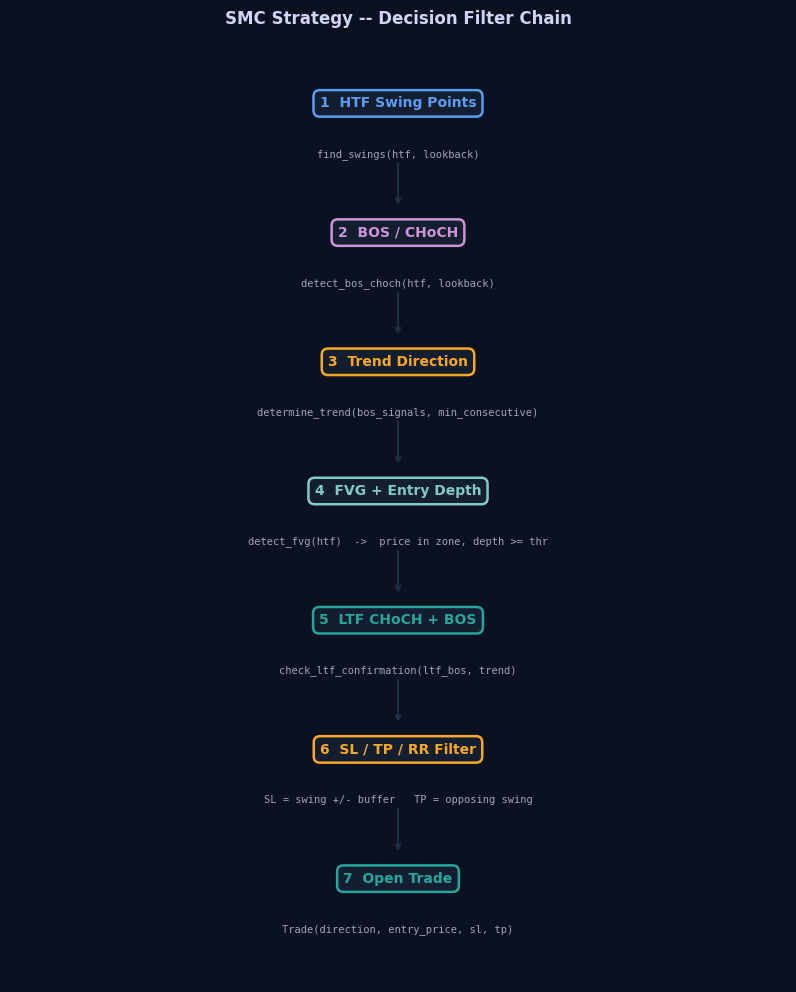

In [17]:
fig, ax = plt.subplots(figsize=(8, 10), facecolor=BG)
ax.set_facecolor(BG); ax.axis('off')
ax.set_xlim(0, 10); ax.set_ylim(-0.5, 14.5)

_steps = [
    ('1  HTF Swing Points',    'find_swings(htf, lookback)',                          BLUE),
    ('2  BOS / CHoCH',         'detect_bos_choch(htf, lookback)',                    PURPLE),
    ('3  Trend Direction',     'determine_trend(bos_signals, min_consecutive)',       GOLD),
    ('4  FVG + Entry Depth',   'detect_fvg(htf)  ->  price in zone, depth >= thr',  CYAN),
    ('5  LTF CHoCH + BOS',     'check_ltf_confirmation(ltf_bos, trend)',             GREEN),
    ('6  SL / TP / RR Filter', 'SL = swing +/- buffer   TP = opposing swing',        GOLD),
    ('7  Open Trade',          'Trade(direction, entry_price, sl, tp)',              GREEN),
]
ys = [13, 11, 9, 7, 5, 3, 1]
for y, (title, code, color) in zip(ys, _steps):
    ax.text(5, y + 0.1, title, color=color, fontsize=10, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.45', fc=BG2, ec=color, lw=1.8))
    ax.text(5, y - 0.6, code, color=FG, fontsize=7.5, ha='center', va='top',
            alpha=0.75, fontfamily='monospace')
for ya, yb in zip(ys[:-1], ys[1:]):
    ax.annotate('', xy=(5, yb + 0.48), xytext=(5, ya - 0.78),
                arrowprops=dict(arrowstyle='->', color=GRID, lw=1.5))

ax.set_title('SMC Strategy -- Decision Filter Chain', color=FG, fontsize=12, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


## Step 1 — HTF 摆动高低点 (`find_swings`)

第 `i` 根K线，若其高点是前后 `lookback` 根K线中最高的 → 摆动高点（▲）；低点同理（▼）。
然后强制交替排列（高→低→高→低…）。

`lookback` 越大 → 识别越平滑，但信号越稀疏。

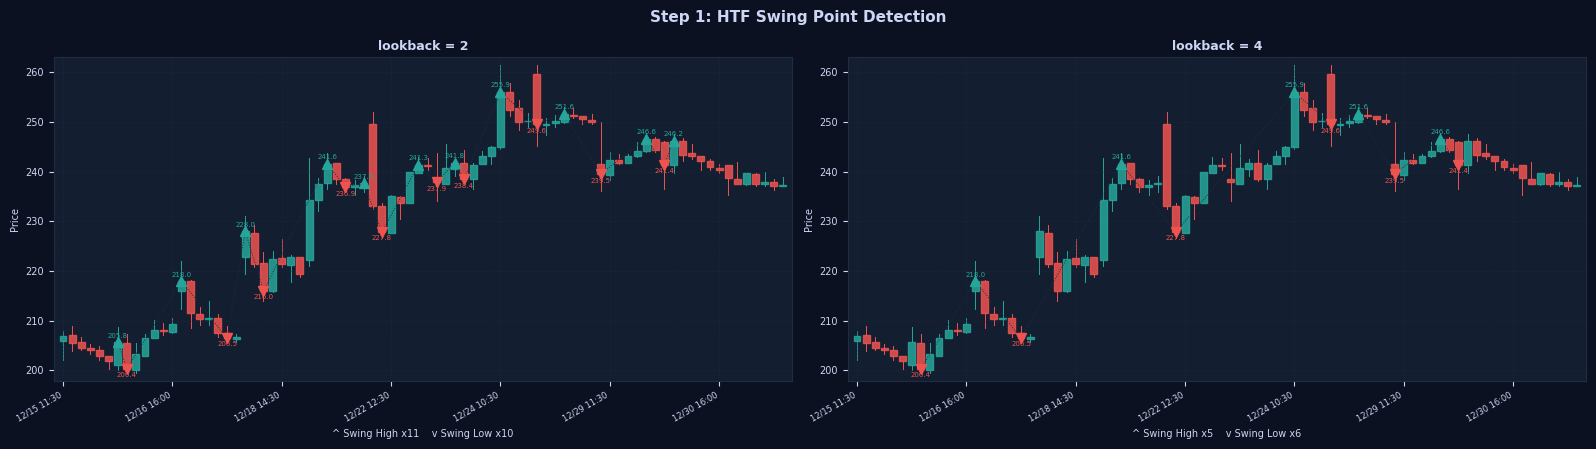

In [18]:
htf = htf_raw.tail(80).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), facecolor=BG)
for ax, lb in zip(axes, [2, 4]):
    swings = find_swings(htf, lookback=lb)
    draw_candles(ax, htf)
    style_ax(ax, f'lookback = {lb}')
    time_ticks(ax, htf, step=12)

    for sw in swings:
        if sw['kind'] == 'high':
            ax.plot(sw['idx'], sw['price'], '^', color=GREEN, ms=7, zorder=5)
            ax.text(sw['idx'], sw['price'] * 1.003, f"{sw['price']:.1f}",
                    color=GREEN, fontsize=5, ha='center', va='bottom')
        else:
            ax.plot(sw['idx'], sw['price'], 'v', color=RED, ms=7, zorder=5)
            ax.text(sw['idx'], sw['price'] * 0.997, f"{sw['price']:.1f}",
                    color=RED, fontsize=5, ha='center', va='top')

    xs = [s['idx'] for s in swings]
    ys = [s['price'] for s in swings]
    ax.plot(xs, ys, color=GRID, lw=0.7, ls=':', zorder=3)

    nh = sum(1 for s in swings if s['kind'] == 'high')
    nl = sum(1 for s in swings if s['kind'] == 'low')
    ax.set_xlabel(f'^ Swing High x{nh}    v Swing Low x{nl}', fontsize=7)
    ax.set_ylabel('Price', fontsize=7)

plt.suptitle('Step 1: HTF Swing Point Detection', color=FG, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 2 — BOS / CHoCH (`detect_bos_choch`)

| 信号 | 条件 | 含义 |
|------|------|------|
| **BOS ↑** | 顺势突破前摆动高点 | 上涨结构延续 |
| **BOS ↓** | 顺势跌破前摆动低点 | 下跌结构延续 |
| **CHoCH ↑** | 下跌途中突破前高 | 结构反转 → 转牛 |
| **CHoCH ↓** | 上涨途中跌破前低 | 结构反转 → 转熊 |

实线 = BOS，虚线 = CHoCH。

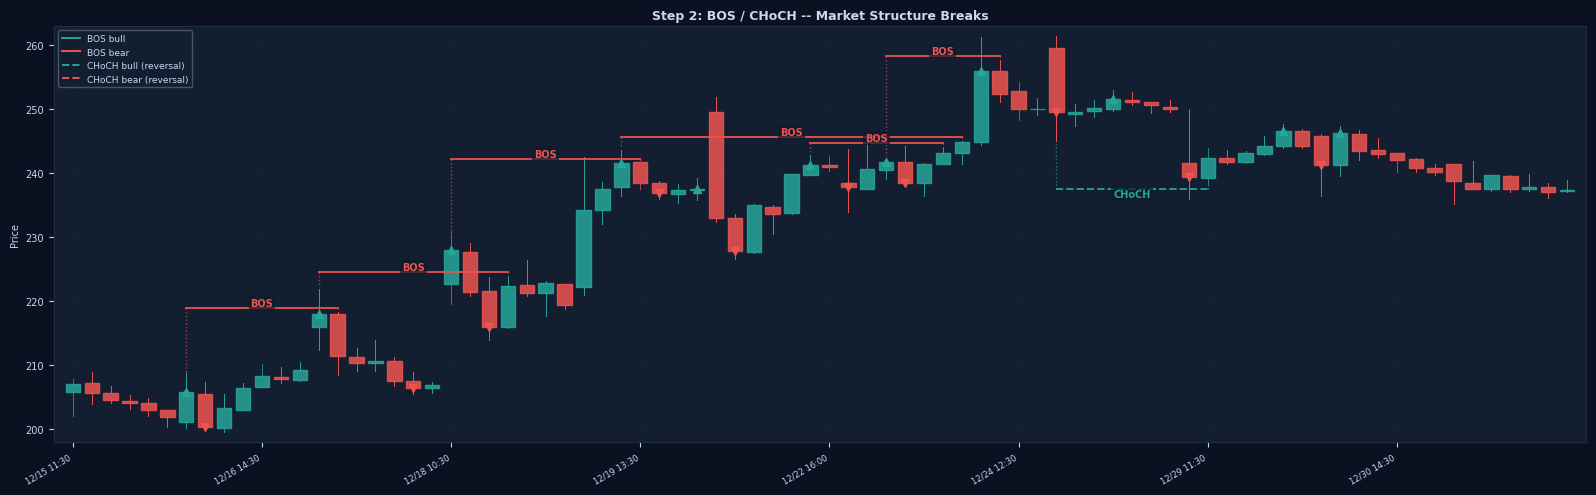

In [19]:
swings  = find_swings(htf, lookback=2)
signals = detect_bos_choch(htf, lookback=2)

fig, ax = plt.subplots(figsize=(16, 5), facecolor=BG)
draw_candles(ax, htf)
style_ax(ax, 'Step 2: BOS / CHoCH -- Market Structure Breaks')
time_ticks(ax, htf, step=10)

for sw in swings:
    m = '^' if sw['kind'] == 'high' else 'v'
    c = GREEN if sw['kind'] == 'high' else RED
    ax.plot(sw['idx'], sw['price'], m, color=c, ms=6, zorder=5)

draw_bos_choch(ax, htf, signals)

items = [
    matplotlib.lines.Line2D([0],[0], color=GREEN, lw=1.4, ls='-',  label='BOS bull'),
    matplotlib.lines.Line2D([0],[0], color=RED,   lw=1.4, ls='-',  label='BOS bear'),
    matplotlib.lines.Line2D([0],[0], color=GREEN, lw=1.4, ls='--', label='CHoCH bull (reversal)'),
    matplotlib.lines.Line2D([0],[0], color=RED,   lw=1.4, ls='--', label='CHoCH bear (reversal)'),
]
leg = ax.legend(handles=items, fontsize=6.5, framealpha=0.3, labelcolor=FG, loc='upper left')
leg.get_frame().set_facecolor(BG2)
ax.set_ylabel('Price', fontsize=7)
plt.tight_layout()
plt.show()


## Step 3 — 趋势判断 (`determine_trend`)

遍历 BOS/CHoCH 序列：
- **CHoCH** → 重置方向，连续计数归 1
- 同向 **BOS** → 计数 +1
- 计数 ≥ `min_consecutive` 才输出有效趋势

背景色：绿 = 当前趋势判断为牛，红 = 熊，灰 = 无确定趋势。

{"idx":>5}  {"type":>6}  {"dir":>5}  {"price":>8}   min=1      min=2
----------------------------------------------------------
   14     BOS   bull    208.80           -          -
   23     BOS   bull    221.99           -          -
   30     BOS   bull    231.00           -          -
   46     BOS   bull    242.86           -          -
   47     BOS   bull    243.71           -          -
   49     BOS   bull    242.47           -          -
   60   CHoCH   bear    245.10        bear          -


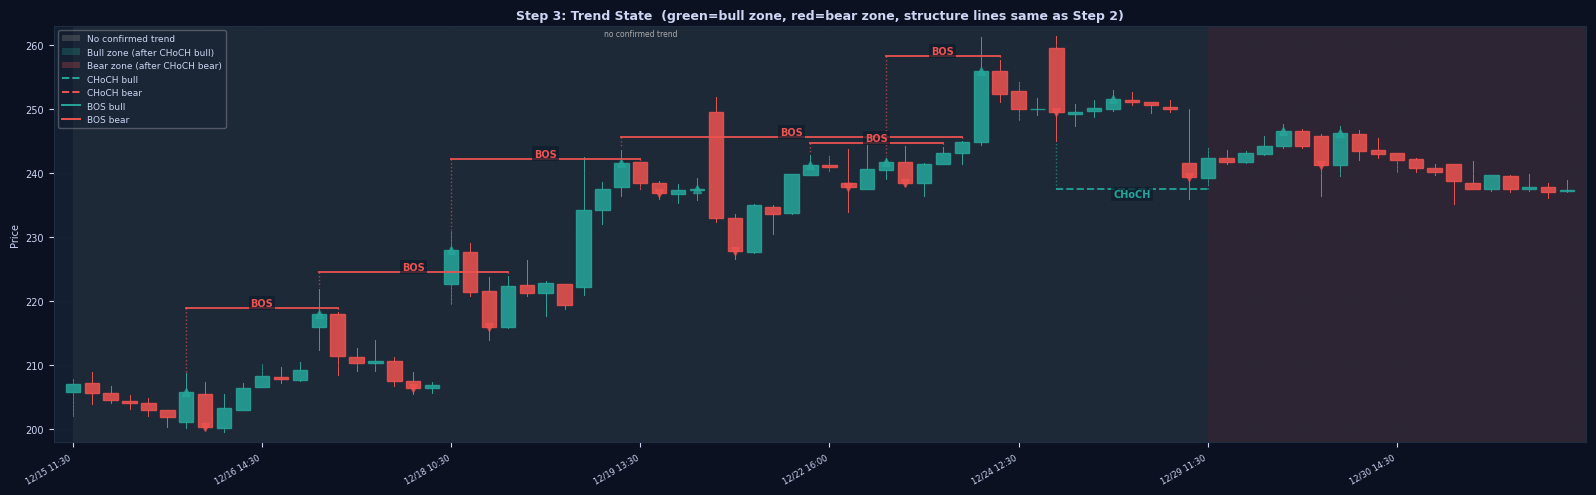

In [20]:
print(f'{{"idx":>5}}  {{"type":>6}}  {{"dir":>5}}  {{"price":>8}}   min=1      min=2')
print('-' * 58)
t1 = t2 = None; c1 = c2 = 0
for sig in sorted(signals, key=lambda s: s['idx']):
    if sig['type'] == 'CHoCH':
        t1 = t2 = sig['direction']; c1 = c2 = 1
    elif sig['type'] == 'BOS':
        if sig['direction'] == t1: c1 += 1
        if sig['direction'] == t2: c2 += 1
    o1 = (t1 or '-') if (t1 and c1 >= 1) else '-'
    o2 = (t2 or '-') if (t2 and c2 >= 2) else '-'
    print(f"{sig['idx']:>5}  {sig['type']:>6}  {sig['direction']:>5}  "
          f"{sig['price']:>8.2f}   {o1:>9}  {o2:>9}")

fig, ax = plt.subplots(figsize=(16, 5), facecolor=BG)
draw_candles(ax, htf)
style_ax(ax, 'Step 3: Trend State  (green=bull zone, red=bear zone, structure lines same as Step 2)')
time_ticks(ax, htf, step=10)

# Background trend zones
_sigs_sorted = sorted(signals, key=lambda s: s['idx'])
_first_choch = next((s['idx'] for s in _sigs_sorted if s['type'] == 'CHoCH'), None)
if _first_choch:
    ax.axvspan(0, _first_choch, facecolor='#888888', alpha=0.10)
    ax.text(_first_choch / 2, ax.get_ylim()[1] * 0.998,
            'no confirmed trend', color='#aaaaaa', fontsize=5.5, ha='center', va='top')

cur = None; prev_x = 0
for sig in _sigs_sorted:
    if cur is not None:
        ax.axvspan(prev_x, sig['idx'],
                   facecolor=GREEN if cur == 'bull' else RED, alpha=0.12)
    if sig['type'] == 'CHoCH':
        cur = sig['direction']
    prev_x = sig['idx']
if cur:
    ax.axvspan(prev_x, len(htf),
               facecolor=GREEN if cur == 'bull' else RED, alpha=0.12)

# Swing point markers
swings_htf = find_swings(htf, lookback=2)
for sw in swings_htf:
    m = '^' if sw['kind'] == 'high' else 'v'
    c = GREEN if sw['kind'] == 'high' else RED
    ax.plot(sw['idx'], sw['price'], m, color=c, ms=6, zorder=5, alpha=0.7)

# BOS / CHoCH structure lines (trade_viewer style)
draw_bos_choch(ax, htf, signals)

items = [
    mpatches.Patch(fc='#888888', alpha=0.3,  label='No confirmed trend'),
    mpatches.Patch(fc=GREEN,     alpha=0.25, label='Bull zone (after CHoCH bull)'),
    mpatches.Patch(fc=RED,       alpha=0.25, label='Bear zone (after CHoCH bear)'),
    matplotlib.lines.Line2D([0],[0], color=GREEN, lw=1.4, ls='--', label='CHoCH bull'),
    matplotlib.lines.Line2D([0],[0], color=RED,   lw=1.4, ls='--', label='CHoCH bear'),
    matplotlib.lines.Line2D([0],[0], color=GREEN, lw=1.4, ls='-',  label='BOS bull'),
    matplotlib.lines.Line2D([0],[0], color=RED,   lw=1.4, ls='-',  label='BOS bear'),
]
leg = ax.legend(handles=items, fontsize=6.5, framealpha=0.3, labelcolor=FG, loc='upper left')
leg.get_frame().set_facecolor(BG2)
ax.set_ylabel('Price', fontsize=7)
plt.tight_layout()
plt.show()


## Step 4 — FVG 公允价值缺口 (`detect_fvg`)

**三根K线模式**：
- **牛FVG**：`high[i-2] < low[i]`，中间K线向上跳空留下缺口 → 绿色区域
- **熊FVG**：`low[i-2] > high[i]`，中间K线向下跳空留下缺口 → 红色区域

价格**回拉进入 FVG** 时寻找入场信号（SMC 核心逻辑）。
浅色 = 已被后续K线填满（失效），深色 = 仍有效。

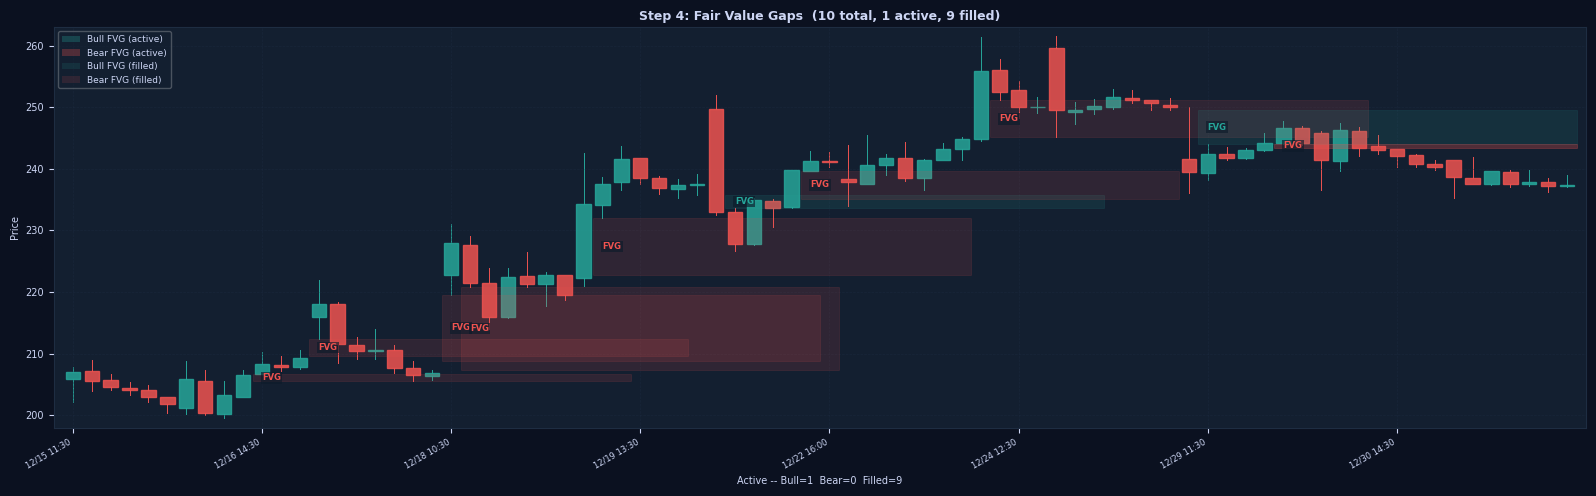

In [21]:
fvgs = detect_fvg(htf, min_gap_pct=0.002)

fig, ax = plt.subplots(figsize=(16, 5), facecolor=BG)
draw_candles(ax, htf)
n_active = sum(1 for f in fvgs if not f['filled'])
style_ax(ax, f'Step 4: Fair Value Gaps  ({len(fvgs)} total, {n_active} active, {len(fvgs)-n_active} filled)')
time_ticks(ax, htf, step=10)

draw_fvg(ax, htf, fvgs)

n_bull   = sum(1 for f in fvgs if f['direction'] == 'bull' and not f['filled'])
n_bear   = sum(1 for f in fvgs if f['direction'] == 'bear' and not f['filled'])
n_filled = sum(1 for f in fvgs if f['filled'])
ax.set_xlabel(f'Active -- Bull={n_bull}  Bear={n_bear}  Filled={n_filled}', fontsize=7)

items = [
    mpatches.Patch(fc=GREEN, alpha=0.28, label='Bull FVG (active)'),
    mpatches.Patch(fc=RED,   alpha=0.28, label='Bear FVG (active)'),
    mpatches.Patch(fc=GREEN, alpha=0.13, label='Bull FVG (filled)'),
    mpatches.Patch(fc=RED,   alpha=0.13, label='Bear FVG (filled)'),
]
leg = ax.legend(handles=items, fontsize=6.5, framealpha=0.3, labelcolor=FG, loc='upper left')
leg.get_frame().set_facecolor(BG2)
ax.set_ylabel('Price', fontsize=7)
plt.tight_layout()
plt.show()


## Step 5 — FVG Entry Depth (`fvg_entry_depth`)

FVG 进入以**影线**为准：

- **牛FVG**（价格从上方回落）：用 `bar_low`（下影线）判断是否触及 FVG，`depth = (top − low) / size`
- **熊FVG**（价格从下方反弹）：用 `bar_high`（上影线）判断是否触及 FVG，`depth = (high − bottom) / size`

`depth=0` 刚碰到边缘，`depth=1` 影线完全穿透（此时 clamp 为 1.0）。  
参数 `fvg_entry_depth_pct=0.20` 要求影线至少穿入 20%。  
收盘价不需要进入 FVG —— 影线触及即触发后续确认流程。

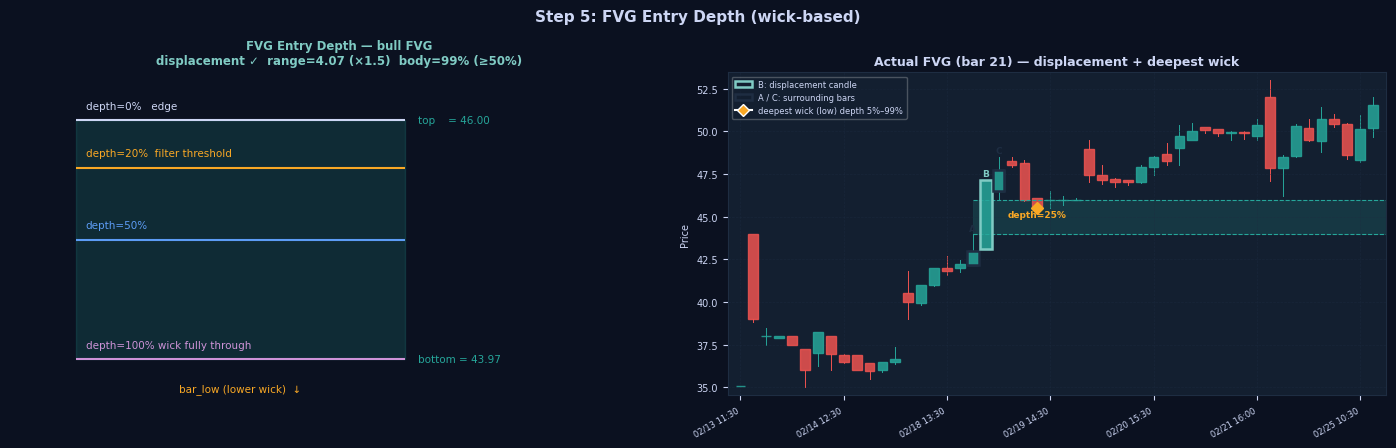

FVG bar 21: bottom=43.970  top=46.000  size=2.0300  dir=bull
Middle candle: range=4.070  body=4.040  body_ratio=0.99  displacement=True
Deepest wick : bar 24  low=45.500  depth=0.25

Depth reference table:
  depth=0.0  low=46.000  -> fvg_entry_depth=0.00
  depth=0.2  low=45.594  -> fvg_entry_depth=0.20
  depth=0.5  low=44.985  -> fvg_entry_depth=0.50
  depth=1.0  low=43.970  -> fvg_entry_depth=1.00


In [22]:
_DISP_MULT  = 1.5   # range multiplier — matches BacktestParams.displacement_atr_mult
_BODY_RATIO = 0.5   # body/range minimum — matches BacktestParams.displacement_body_ratio
_MIN_DEPTH = 0.05  # wick must enter at least this far into the FVG
_MAX_DEPTH = 0.99  # exclude full-penetration (depth=100%) from demo
_WARMUP    = 20    # skip first N bars — dataset edge may have incomplete data

# Search htf_raw for a displacement FVG with a qualifying wick entry.
htf_demo = htf_raw.reset_index(drop=True)
all_fvgs  = detect_fvg(htf_demo, min_gap_pct=0.002)

demo = None
for f in all_fvgs:
    if f['idx'] < _WARMUP:          # skip dataset warmup region
        continue
    if not is_displacement_candle(htf_demo, f['idx'], _DISP_MULT, _BODY_RATIO):
        continue
    _idx, _bot, _top = f['idx'], f['bottom'], f['top']
    _bull = f['direction'] == 'bull'
    for j in range(_idx + 1, min(len(htf_demo), _idx + 30)):
        r   = htf_demo.iloc[j]
        wp  = r['low'] if _bull else r['high']
        ov  = (_bull and wp <= _top and r['high'] >= _bot) or \
              (not _bull and wp >= _bot and r['low'] <= _top)
        if ov and _MIN_DEPTH <= fvg_entry_depth(f, wp) <= _MAX_DEPTH:
            demo = f
            break
    if demo is not None:
        break

# Final fallback: first unfilled FVG in the 80-bar window
if demo is None:
    demo = next((f for f in detect_fvg(htf, min_gap_pct=0.002) if not f['filled']), None)
    htf_demo = htf

if demo is None:
    print('No FVG available for demo')
else:
    bot, top = demo['bottom'], demo['top']
    size = top - bot
    bull = demo['direction'] == 'bull'
    wick_col = 'low' if bull else 'high'
    idx  = demo['idx']

    mid_bar   = htf_demo.iloc[idx - 1]
    mid_range = mid_bar['high'] - mid_bar['low']
    mid_body  = abs(mid_bar['close'] - mid_bar['open'])
    body_ratio = mid_body / mid_range if mid_range > 0 else 0.0
    is_disp   = is_displacement_candle(htf_demo, idx, _DISP_MULT, _BODY_RATIO)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), facecolor=BG)

    # ── Left: schematic ───────────────────────────────────────────────────
    ax = axes[0]
    ax.set_facecolor(BG2); ax.set_xlim(0, 10); ax.set_ylim(-0.15, 1.20); ax.axis('off')
    color = GREEN if bull else RED
    ax.add_patch(mpatches.Rectangle((1, 0), 5, 1, fc=color, ec=color, alpha=0.18, zorder=1))
    ax.hlines([0, 1], 1, 6, colors=color, lw=1.4, ls='--', zorder=2)
    ax.text(6.2, 0, f'bottom = {bot:.2f}', color=color, fontsize=7.5, va='center')
    ax.text(6.2, 1, f'top    = {top:.2f}', color=color, fontsize=7.5, va='center')
    for d, c, lbl in [(0.0, FG, 'depth=0%   edge'), (0.2, GOLD, 'depth=20%  filter threshold'),
                      (0.5, BLUE, 'depth=50%'), (1.0, PURPLE, 'depth=100% wick fully through')]:
        y_norm = (1 - d) if bull else d
        ax.hlines(y_norm, 1, 6, colors=c, lw=1.5, zorder=3)
        ax.text(1.15, y_norm + 0.04, lbl, color=c, fontsize=7.5, va='bottom')
    wick_lbl = 'bar_low (lower wick)  ↓' if bull else 'bar_high (upper wick)  ↑'
    ax.text(3.5, -0.10, wick_lbl, color=GOLD, fontsize=7.5, ha='center', va='top')

    disp_tag = (
        f'displacement ✓  range={mid_range:.2f} (×{_DISP_MULT})  '
        f'body={body_ratio:.0%} (≥{_BODY_RATIO:.0%})'
        if is_disp else
        f'displacement ✗  range={mid_range:.2f}  body={body_ratio:.0%}'
    )
    ax.set_title(f'FVG Entry Depth — {demo["direction"]} FVG\n{disp_tag}',
                 color=CYAN if is_disp else RED, fontsize=8.5, fontweight='bold', pad=6)

    # ── Right: 3-bar pattern + deepest wick ──────────────────────────────
    ax2 = axes[1]
    ws  = max(0, idx - 20)
    we  = min(len(htf_demo), idx + 30)
    win = htf_demo.iloc[ws:we].reset_index(drop=True)
    draw_candles(ax2, win, x0=ws)
    style_ax(ax2, f'Actual FVG (bar {idx}) — displacement + deepest wick')
    time_ticks(ax2, win, step=8, x0=ws)
    ax2.add_patch(mpatches.Rectangle(
        (idx - 2, bot), len(htf_demo) - (idx - 2), size,
        fc=color, ec=color, alpha=0.18, lw=0.5))
    ax2.hlines([bot, top], idx - 2, ws + len(win), colors=color, lw=0.8, ls='--')

    # Highlight the 3-bar FVG pattern (A, B=displacement, C)
    for bar_abs, lbl_txt, ec_col in [(idx-2,'A',GRID),(idx-1,'B',CYAN),(idx,'C',GRID)]:
        bar_j = bar_abs - ws
        if 0 <= bar_j < len(win):
            r  = win.iloc[bar_j]
            lo = min(r['open'], r['close'])
            hi = max(r['open'], r['close'])
            ax2.add_patch(mpatches.Rectangle(
                (bar_abs - 0.45, lo), 0.90, max(hi - lo, 1e-6),
                fill=False, ec=ec_col, lw=1.8, zorder=7))
            ax2.text(bar_abs, r['high'] * 1.002, lbl_txt,
                     color=ec_col, fontsize=6.5, ha='center', va='bottom', fontweight='bold')

    # Deepest qualifying wick after FVG formation
    fvg_j = idx - ws
    best_j, best_depth, best_wick = -1, -1.0, None
    for j in range(fvg_j + 1, len(win)):
        row = win.iloc[j]
        wick_price = row['low'] if bull else row['high']
        overlaps = (bull     and wick_price <= top and row['high'] >= bot) or \
                   (not bull and wick_price >= bot and row['low']  <= top)
        if overlaps:
            d = fvg_entry_depth(demo, wick_price)
            if _MIN_DEPTH <= d <= _MAX_DEPTH and d > best_depth:
                best_j, best_depth, best_wick = j, d, wick_price

    if best_j >= 0:
        xb = ws + best_j
        ax2.plot(xb, best_wick, 'D', color=GOLD, ms=6, zorder=8)
        va  = 'top' if bull else 'bottom'
        off = best_wick * (0.997 if bull else 1.003)
        ax2.text(xb, off, f'depth={best_depth:.0%}',
                 color=GOLD, fontsize=6.5, ha='center', va=va, fontweight='bold')

    ax2.set_ylabel('Price', fontsize=7)
    legend_items = [
        mpatches.Patch(fc='none', ec=CYAN, lw=1.8, label='B: displacement candle'),
        mpatches.Patch(fc='none', ec=GRID, lw=1.8, label='A / C: surrounding bars'),
        matplotlib.lines.Line2D([0], [0], marker='D', color='w', markerfacecolor=GOLD,
                                ms=6, label=f'deepest wick ({wick_col}) depth {_MIN_DEPTH:.0%}–{_MAX_DEPTH:.0%}'),
    ]
    leg = ax2.legend(handles=legend_items, fontsize=6, framealpha=0.3, labelcolor=FG, loc='upper left')
    leg.get_frame().set_facecolor(BG2)

    plt.suptitle('Step 5: FVG Entry Depth (wick-based)', color=FG, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'FVG bar {idx}: bottom={bot:.3f}  top={top:.3f}  size={size:.4f}  dir={demo["direction"]}')
    print(f'Middle candle: range={mid_range:.3f}  body={mid_body:.3f}  body_ratio={body_ratio:.2f}  displacement={is_disp}')
    if best_j >= 0:
        print(f'Deepest wick : bar {ws+best_j}  {wick_col}={best_wick:.3f}  depth={best_depth:.2f}')
    else:
        print('No qualifying wick entry found in window')
    print('\nDepth reference table:')
    for d in [0.0, 0.2, 0.5, 1.0]:
        p = (top - d * size) if bull else (bot + d * size)
        print(f'  depth={d:.1f}  {wick_col}={p:.3f}  -> fvg_entry_depth={fvg_entry_depth(demo, p):.2f}')


## Step 6 — 入场深度 × 确认模式

**两种入场确认策略对比：**

| 模式 | 逻辑 | 参数 |
|------|------|------|
| `CHoCH+BOS` | wick 进入 FVG 后等待 LTF 结构反转确认 | `require_ltf_confirmation=True` |
| `depth-only` | wick 穿入 FVG 达到指定深度即入场 | `require_ltf_confirmation=False` |

扫描 `fvg_entry_depth_pct` ∈ [5%, 10%, 20%, 30%, 50%, 70%] × 两种模式，其余参数固定。

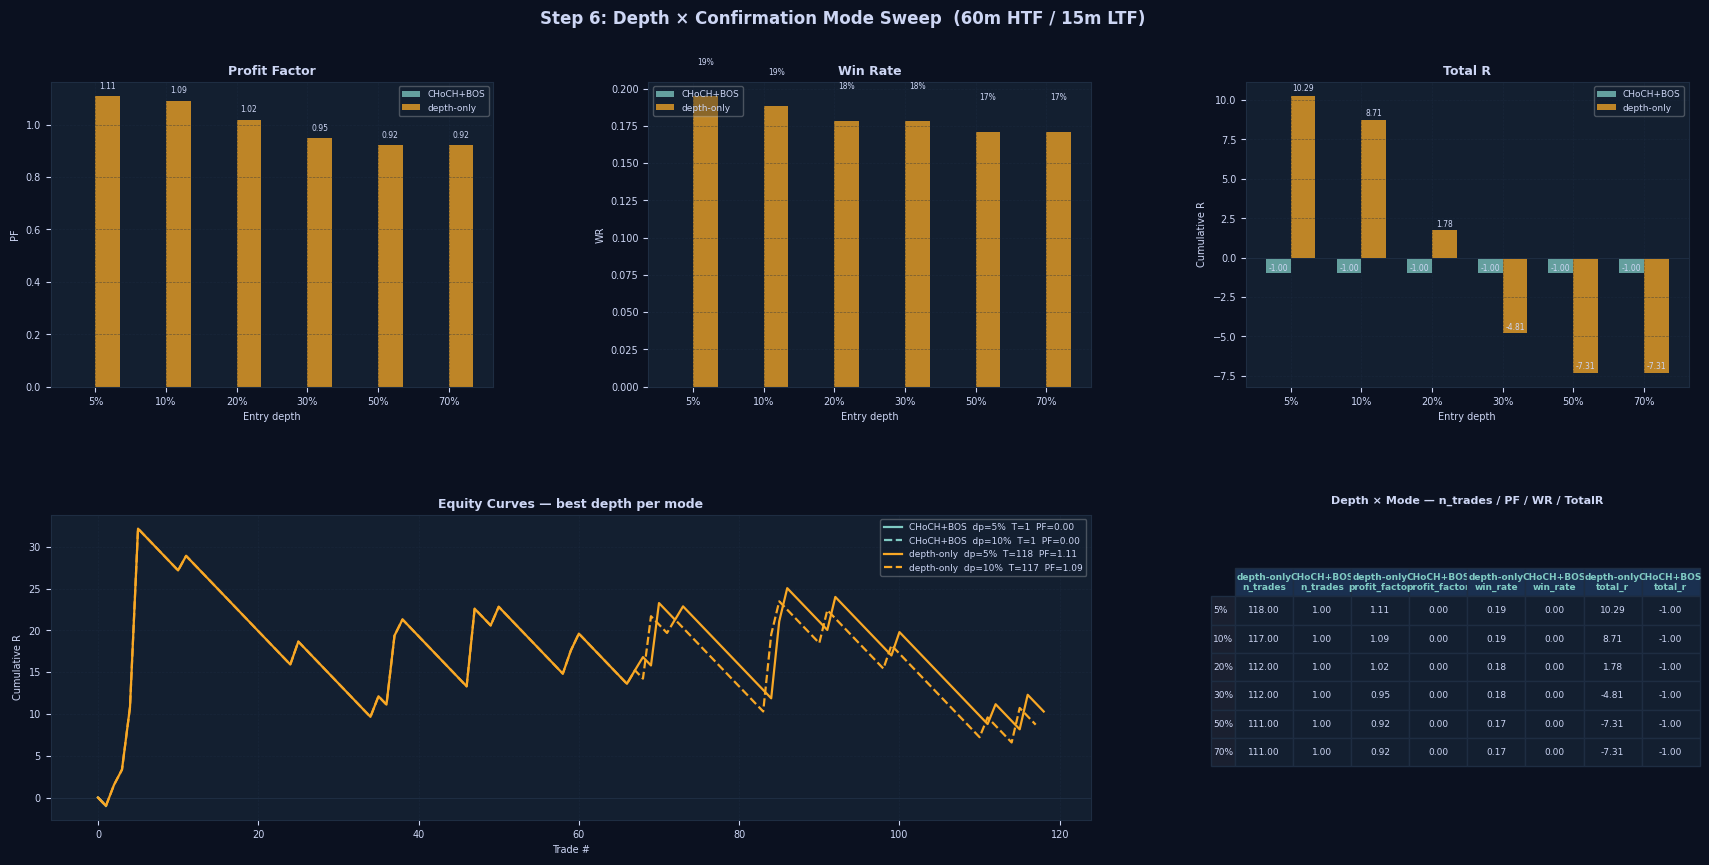

 depth  conf  n_trades  win_rate   total_r  profit_factor    max_dd     avg_r
  0.05  True         1  0.000000 -1.000000       0.000000  1.000000 -1.000000
  0.10  True         1  0.000000 -1.000000       0.000000  1.000000 -1.000000
  0.20  True         1  0.000000 -1.000000       0.000000  1.000000 -1.000000
  0.30  True         1  0.000000 -1.000000       0.000000  1.000000 -1.000000
  0.50  True         1  0.000000 -1.000000       0.000000  1.000000 -1.000000
  0.70  True         1  0.000000 -1.000000       0.000000  1.000000 -1.000000
  0.05 False       118  0.194915 10.286117       1.108275 24.004439  0.087170
  0.10 False       117  0.188034  8.710876       1.091693 25.579680  0.074452
  0.20 False       112  0.178571  1.784985       1.019402 32.505571  0.015937
  0.30 False       112  0.178571 -4.807130       0.947749 39.097686 -0.042921
  0.50 False       111  0.171171 -7.307130       0.920575 39.097686 -0.065830
  0.70 False       111  0.171171 -7.307130       0.920575 39.097

In [23]:
import itertools
import pandas as pd

DEPTHS     = [0.05, 0.10, 0.20, 0.30, 0.50, 0.70]
CONF_MODES = [True, False]
BASE = dict(trend_tf="60m", entry_tf="15m",
            swing_lookback=2, bos_count=1,
            fvg_min_width_pct=0.002,
            sl_buffer_pct=0.001, max_sl_pct=0.010, min_rr=1.5)

# ── Run grid ────────────────────────────────────────────────────────────────
records   = []
trade_map = {}
for conf, depth in itertools.product(CONF_MODES, DEPTHS):
    p = BacktestParams(**BASE, fvg_entry_depth_pct=depth,
                       require_ltf_confirmation=conf)
    r = run_backtest(htf_raw, ltf_raw, p)
    records.append(dict(
        depth=depth, conf=conf,
        n_trades=r.n_trades, win_rate=r.win_rate,
        total_r=r.total_r, profit_factor=r.profit_factor,
        max_dd=r.max_drawdown_r, avg_r=r.avg_r,
    ))
    trade_map[(depth, conf)] = [t.r_multiple for t in r.trades]

df_sweep = pd.DataFrame(records)

# ── Layout ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 9), facecolor=BG)
gs  = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.35,
                        left=0.06, right=0.97, top=0.90, bottom=0.08)
ax_pf  = fig.add_subplot(gs[0, 0])
ax_wr  = fig.add_subplot(gs[0, 1])
ax_tr  = fig.add_subplot(gs[0, 2])
ax_eq  = fig.add_subplot(gs[1, 0:2])
ax_tbl = fig.add_subplot(gs[1, 2])

CONF_COLOR = {True: CYAN, False: GOLD}
CONF_LABEL = {True: "CHoCH+BOS", False: "depth-only"}
bar_w = 0.35
x     = np.arange(len(DEPTHS))

def _vals(conf, col):
    return [df_sweep.loc[(df_sweep.conf == conf) & (df_sweep.depth == d), col].values[0]
            for d in DEPTHS]

for ax, col, title, ylbl in [
    (ax_pf, "profit_factor", "Profit Factor", "PF"),
    (ax_wr, "win_rate",      "Win Rate",      "WR"),
    (ax_tr, "total_r",       "Total R",       "Cumulative R"),
]:
    style_ax(ax, title)
    for conf, offset in [(True, -bar_w / 2), (False, bar_w / 2)]:
        vals = _vals(conf, col)
        bars = ax.bar(x + offset, vals, width=bar_w,
                      color=CONF_COLOR[conf], alpha=0.75,
                      label=CONF_LABEL[conf])
        for bar, v in zip(bars, vals):
            if v != 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + max(abs(v) * 0.02, 0.02),
                        f"{v:.2f}" if col != "win_rate" else f"{v:.0%}",
                        ha="center", va="bottom", fontsize=5.5, color=FG)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{d:.0%}" for d in DEPTHS], fontsize=7)
    ax.set_xlabel("Entry depth", fontsize=7)
    ax.set_ylabel(ylbl, fontsize=7)
    ax.axhline(0, color=GRID, lw=0.7)
    ax.legend(fontsize=6.5, framealpha=0.3, labelcolor=FG)

style_ax(ax_eq, "Equity Curves — best depth per mode")
ax_eq.axhline(0, color=GRID, lw=0.8)
for conf in CONF_MODES:
    sub = df_sweep[df_sweep.conf == conf].copy()
    sub = sub[sub.n_trades > 0].sort_values("profit_factor", ascending=False)
    for rank, (_, row) in enumerate(sub.head(2).iterrows()):
        rs = trade_map[(row.depth, conf)]
        if not rs:
            continue
        eq  = np.concatenate([[0], np.cumsum(rs)])
        lbl = (f"{CONF_LABEL[conf]}  dp={row.depth:.0%}  "
               f"T={row.n_trades}  PF={row.profit_factor:.2f}")
        ax_eq.plot(eq, color=CONF_COLOR[conf], lw=1.6,
                   ls="-" if rank == 0 else "--", label=lbl)
ax_eq.legend(fontsize=6.5, framealpha=0.3, labelcolor=FG)
ax_eq.set_xlabel("Trade #", fontsize=7)
ax_eq.set_ylabel("Cumulative R", fontsize=7)

ax_tbl.set_facecolor(BG2)
ax_tbl.axis("off")
pivot = df_sweep.pivot(index="depth", columns="conf",
                       values=["n_trades", "profit_factor", "win_rate", "total_r"])
pivot.columns = [f"{CONF_LABEL[c]}\n{m}" for m, c in pivot.columns]
pivot.index   = [f"{d:.0%}" for d in pivot.index]
_rows = [[f"{v:.2f}" if isinstance(v, float) else str(int(v))
          for v in row] for row in pivot.values]
tbl = ax_tbl.table(cellText=_rows,
                   rowLabels=list(pivot.index),
                   colLabels=list(pivot.columns),
                   cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(6.5)
tbl.scale(1.05, 1.7)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(GRID)
    if row == 0:
        cell.set_facecolor("#1a3050")
        cell.set_text_props(color=CYAN, fontweight="bold")
    elif col == -1:
        cell.set_facecolor("#1a2030")
        cell.set_text_props(color=FG)
    else:
        cell.set_facecolor(BG2)
        cell.set_text_props(color=FG)
ax_tbl.set_title("Depth × Mode — n_trades / PF / WR / TotalR",
                  color=FG, fontsize=8, fontweight="bold", pad=8)

fig.suptitle("Step 6: Depth × Confirmation Mode Sweep  (60m HTF / 15m LTF)",
             color=FG, fontsize=12, fontweight="bold")
plt.show()
print(df_sweep.to_string(index=False))


## Step 7 — 完整交易设置

| 要素 | 牛市 | 熊市 |
|------|------|------|
| **入场** | LTF BOS 确认 K 线收盘价 | 同左 |
| **止损 SL** | 最近 HTF 摆动低点 × (1 − buffer) | 最近 HTF 摆动高点 × (1 + buffer) |
| **止盈 TP** | 最近 HTF 摆动高点（取最低的一个） | 最近 HTF 摆动低点（取最高的一个） |
| **过滤** | SL% ≤ max_sl_pct，RR ≥ min_rr | 同左 |

Trade: bull  entry_time=2025-02-26 09:45:00
  entry=48.720  SL=48.551  TP=50.075
  RR=8.04  Result=loss  R=-1.00


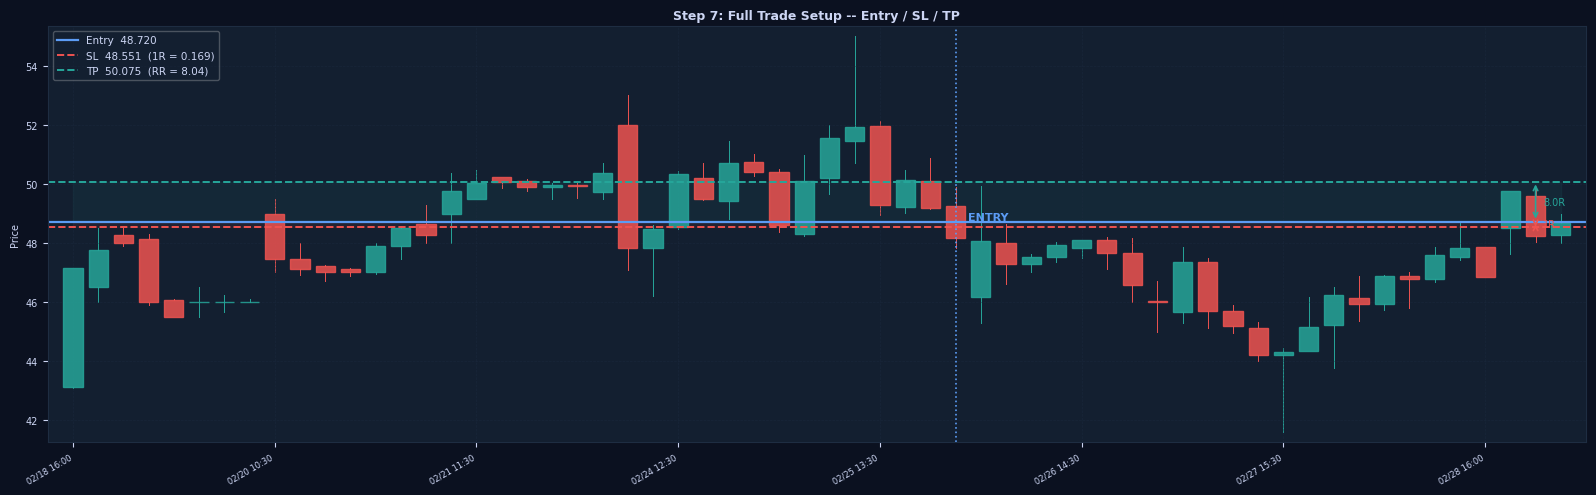

In [24]:
if result.trades:
    trade = result.trades[0]
    entry, sl, tp = trade.entry_price, trade.sl, trade.tp
    direction     = trade.direction
    pos = int((htf_raw['time_key'] <= trade.entry_time).sum()) - 1
    ws  = max(0, pos - 35)
    we  = min(len(htf_raw), pos + 25)
    _htf = htf_raw.iloc[ws:we].reset_index(drop=True)
    entry_bar = pos - ws
    print(f'Trade: {direction}  entry_time={trade.entry_time}')
    print(f'  entry={entry:.3f}  SL={sl:.3f}  TP={tp:.3f}')
    print(f'  RR={trade.planned_rr:.2f}  Result={trade.result}  R={trade.r_multiple:+.2f}')
else:
    _htf = htf.copy()
    mid  = len(_htf) // 2
    entry = _htf.iloc[mid]['close']
    sl    = _htf.iloc[mid]['close'] * 0.97
    tp    = _htf.iloc[mid]['close'] * 1.06
    direction = 'bull'; entry_bar = mid
    print('No real trade found -- using synthetic example')

sl_dist = abs(entry - sl)
rr      = abs(tp - entry) / sl_dist if sl_dist > 0 else 0

fig, ax = plt.subplots(figsize=(16, 5), facecolor=BG)
draw_candles(ax, _htf)
style_ax(ax, 'Step 7: Full Trade Setup -- Entry / SL / TP')
time_ticks(ax, _htf, step=8)

ax.axhline(entry, color=BLUE,  lw=1.6, label=f'Entry  {entry:.3f}')
ax.axhline(sl,    color=RED,   lw=1.4, ls='--', label=f'SL  {sl:.3f}  (1R = {sl_dist:.3f})')
ax.axhline(tp,    color=GREEN, lw=1.4, ls='--', label=f'TP  {tp:.3f}  (RR = {rr:.2f})')
ax.axvline(entry_bar, color=BLUE, lw=1.2, ls=':')
ax.text(entry_bar + 0.5, entry * 1.001, 'ENTRY', color=BLUE, fontsize=8, fontweight='bold')

ax.fill_between(range(len(_htf)), sl,    entry, color=RED,   alpha=0.07)
ax.fill_between(range(len(_htf)), entry, tp,    color=GREEN, alpha=0.07)

xr = len(_htf) - 2
ax.annotate('', xy=(xr, sl), xytext=(xr, entry),
            arrowprops=dict(arrowstyle='<->', color=RED, lw=1.2))
ax.text(xr + 0.3, (sl + entry) / 2, '1R', color=RED, fontsize=7, va='center')
ax.annotate('', xy=(xr, tp), xytext=(xr, entry),
            arrowprops=dict(arrowstyle='<->', color=GREEN, lw=1.2))
ax.text(xr + 0.3, (tp + entry) / 2, f'{rr:.1f}R', color=GREEN, fontsize=7, va='center')

leg = ax.legend(fontsize=7.5, framealpha=0.3, labelcolor=FG, loc='upper left')
leg.get_frame().set_facecolor(BG2)
ax.set_ylabel('Price', fontsize=7)
plt.tight_layout()
plt.show()


## 综合演示 — 多参数对比 + 权益曲线

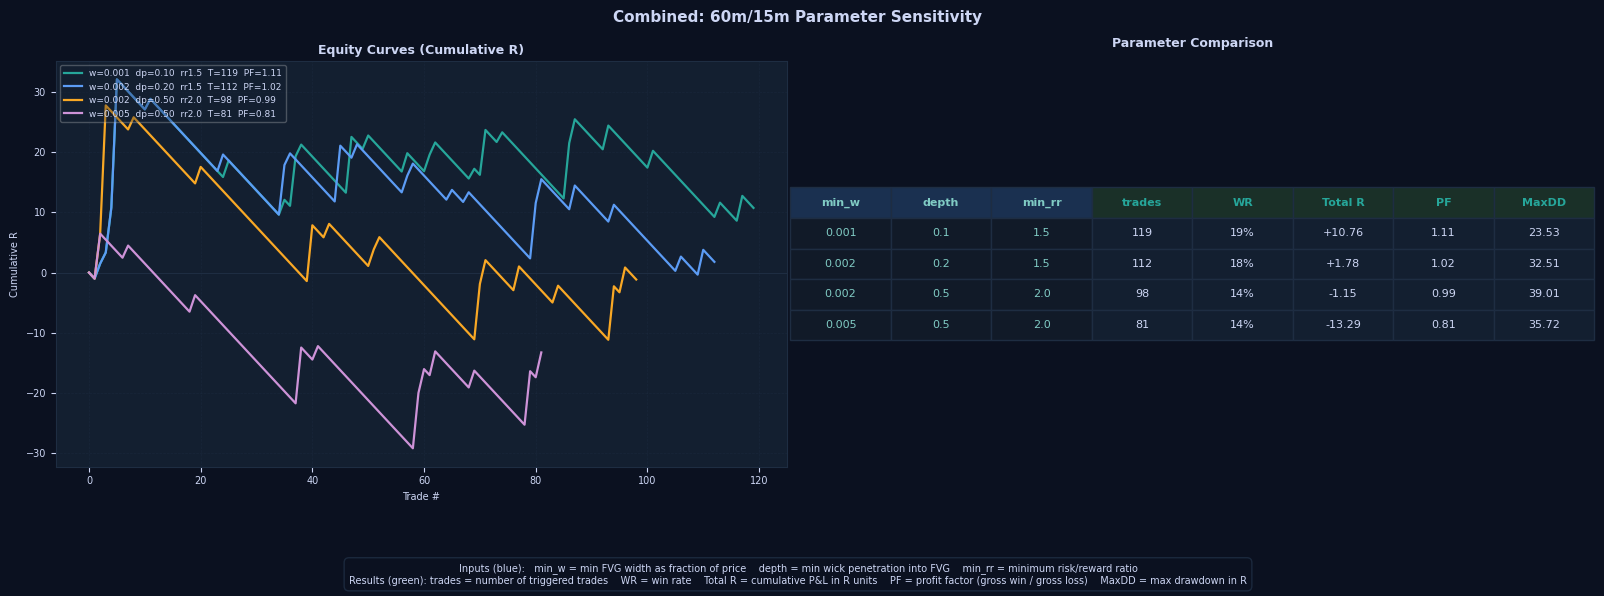

In [25]:
PSETS = [
    dict(fvg_min_width_pct=0.001, fvg_entry_depth_pct=0.10, min_rr=1.5),
    dict(fvg_min_width_pct=0.002, fvg_entry_depth_pct=0.20, min_rr=1.5),
    dict(fvg_min_width_pct=0.002, fvg_entry_depth_pct=0.50, min_rr=2.0),
    dict(fvg_min_width_pct=0.005, fvg_entry_depth_pct=0.50, min_rr=2.0),
]
COLORS4 = [GREEN, BLUE, GOLD, PURPLE]

fig, axes = plt.subplots(1, 2, figsize=(16, 6.0), facecolor=BG)
fig.subplots_adjust(bottom=0.18)
ax_eq  = axes[0]
ax_tbl = axes[1]
style_ax(ax_eq, 'Equity Curves (Cumulative R)')
ax_eq.axhline(0, color=GRID, lw=0.8)

rows = []
for ps, color in zip(PSETS, COLORS4):
    p = BacktestParams(trend_tf='60m', entry_tf='15m',
                       swing_lookback=2, bos_count=1,
                       sl_buffer_pct=0.001, max_sl_pct=0.010, **ps)
    r = run_backtest(htf_raw, ltf_raw, p)
    lbl = (f"w={ps['fvg_min_width_pct']:.3f}  "
           f"dp={ps['fvg_entry_depth_pct']:.2f}  "
           f"rr{ps['min_rr']:.1f}  "
           f"T={r.n_trades}  PF={r.profit_factor:.2f}")
    if r.trades:
        eq = np.concatenate([[0], np.cumsum([t.r_multiple for t in r.trades])])
        ax_eq.plot(eq, color=color, lw=1.6, label=lbl)
    else:
        ax_eq.plot([0], color=color, lw=1, ls=':', label=lbl + '  (no trades)')
    rows.append([ps['fvg_min_width_pct'], ps['fvg_entry_depth_pct'], ps['min_rr'],
                 r.n_trades, f'{r.win_rate:.0%}',
                 f'{r.total_r:+.2f}', f'{r.profit_factor:.2f}', f'{r.max_drawdown_r:.2f}'])

leg = ax_eq.legend(fontsize=6.5, framealpha=0.3, labelcolor=FG, loc='upper left')
leg.get_frame().set_facecolor(BG2)
ax_eq.set_xlabel('Trade #', fontsize=7)
ax_eq.set_ylabel('Cumulative R', fontsize=7)

# ── Table with input-param vs result column colour coding ────────────────────
ax_tbl.set_facecolor(BG2); ax_tbl.axis('off')
_IN  = {0, 1, 2}        # input parameters
_OUT = {3, 4, 5, 6, 7}  # backtest results
_HDR_IN   = '#1a3050'
_HDR_OUT  = '#1a3028'
_CELL_IN  = '#111a28'
_CELL_OUT = BG2

cols = ['min_w', 'depth', 'min_rr', 'trades', 'WR', 'Total R', 'PF', 'MaxDD']
tbl  = ax_tbl.table(cellText=rows, colLabels=cols, cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1.1, 1.9)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(GRID)
    if row == 0:
        cell.set_facecolor(_HDR_IN if col in _IN else _HDR_OUT)
        cell.set_text_props(color=CYAN if col in _IN else GREEN, fontweight='bold')
    else:
        cell.set_facecolor(_CELL_IN if col in _IN else _CELL_OUT)
        cell.set_text_props(color=CYAN if col in _IN else FG)
ax_tbl.set_title('Parameter Comparison', color=FG, fontsize=9, fontweight='bold', pad=10)

# ── Abbreviation legend at figure bottom ─────────────────────────────────────
_abbr = (
    "Inputs (blue):   min_w = min FVG width as fraction of price    "
    "depth = min wick penetration into FVG    "
    "min_rr = minimum risk/reward ratio\n"
    "Results (green): trades = number of triggered trades    "
    "WR = win rate    "
    "Total R = cumulative P&L in R units    "
    "PF = profit factor (gross win / gross loss)    "
    "MaxDD = max drawdown in R"
)
fig.text(0.5, 0.02, _abbr, color=FG, fontsize=7, ha='center', va='bottom',
         bbox=dict(fc=BG, ec=GRID, alpha=0.85, pad=5, boxstyle='round,pad=0.5'))

plt.suptitle('Combined: 60m/15m Parameter Sensitivity', color=FG, fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0.14, 1, 1])
plt.show()


## Step 8 — 止损参数扫描

止损放在**最近的 HTF 摆动低/高点**之外，受两个参数控制：

| 参数 | 说明 |
|------|------|
| `sl_buffer_pct` | SL 超出摆动点的额外缓冲（占价格的百分比）|
| `max_sl_pct` | SL 距入场价超过此比例则跳过该笔交易 |

固定 `depth-only` 模式（`require_ltf_confirmation=False`）和最优深度（`fvg_entry_depth_pct=0.10`），扫描 `sl_buffer_pct` × `max_sl_pct` 组合。

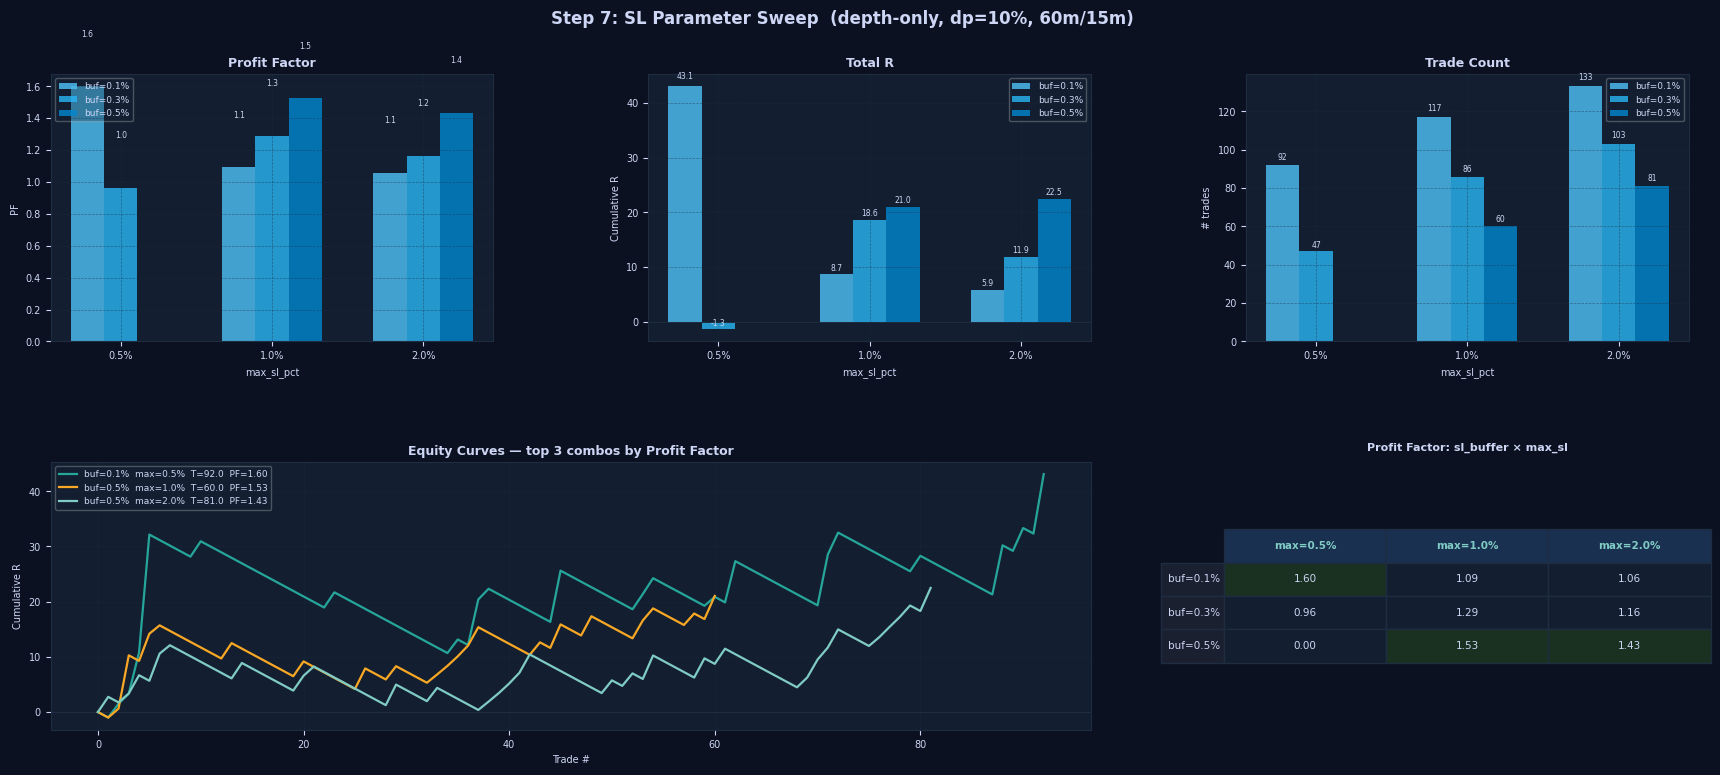

 sl_buf  max_sl  n_trades  win_rate   total_r  profit_factor    max_dd
  0.001   0.005        92  0.217391 43.112673       1.598787 21.471403
  0.001   0.010       117  0.188034  8.710876       1.091693 25.579680
  0.001   0.020       133  0.240602  5.891599       1.058333 24.334515
  0.003   0.005        47  0.191489 -1.348562       0.964512 15.048949
  0.003   0.010        86  0.255814 18.639382       1.291240 20.364042
  0.003   0.020       103  0.291262 11.931773       1.163449 20.817878
  0.005   0.005         0  0.000000  0.000000       0.000000  0.000000
  0.005   0.010        60  0.333333 21.038171       1.525954 11.529708
  0.005   0.020        81  0.358025 22.489089       1.432482 11.723848


In [26]:
SL_BUFFERS  = [0.001, 0.003, 0.005]
MAX_SLS     = [0.005, 0.010, 0.020]
SL_BASE = dict(trend_tf="60m", entry_tf="15m",
               swing_lookback=2, bos_count=1,
               fvg_min_width_pct=0.002,
               fvg_entry_depth_pct=0.10,
               require_ltf_confirmation=False,
               min_rr=1.5)

# ── Run grid ────────────────────────────────────────────────────────────────
sl_records   = []
sl_trade_map = {}
for buf, msl in itertools.product(SL_BUFFERS, MAX_SLS):
    p = BacktestParams(**SL_BASE, sl_buffer_pct=buf, max_sl_pct=msl)
    r = run_backtest(htf_raw, ltf_raw, p)
    sl_records.append(dict(
        sl_buf=buf, max_sl=msl,
        n_trades=r.n_trades, win_rate=r.win_rate,
        total_r=r.total_r, profit_factor=r.profit_factor,
        max_dd=r.max_drawdown_r,
    ))
    sl_trade_map[(buf, msl)] = [t.r_multiple for t in r.trades]

df_sl = pd.DataFrame(sl_records)

# ── Layout ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 8), facecolor=BG)
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35,
                        left=0.06, right=0.97, top=0.90, bottom=0.08)
ax_pf  = fig.add_subplot(gs[0, 0])
ax_tr  = fig.add_subplot(gs[0, 1])
ax_nt  = fig.add_subplot(gs[0, 2])
ax_eq  = fig.add_subplot(gs[1, 0:2])
ax_tbl = fig.add_subplot(gs[1, 2])

BUF_COLORS = ["#4fc3f7", "#29b6f6", "#0288d1"]   # light→dark blue per buffer
bar_w = 0.22
x     = np.arange(len(MAX_SLS))

# ── Bar charts ───────────────────────────────────────────────────────────────
for ax, col, title, ylbl in [
    (ax_pf, "profit_factor", "Profit Factor", "PF"),
    (ax_tr, "total_r",       "Total R",       "Cumulative R"),
    (ax_nt, "n_trades",      "Trade Count",   "# trades"),
]:
    style_ax(ax, title)
    for k, (buf, color) in enumerate(zip(SL_BUFFERS, BUF_COLORS)):
        vals = [df_sl.loc[(df_sl.sl_buf == buf) & (df_sl.max_sl == msl), col].values[0]
                for msl in MAX_SLS]
        offset = (k - 1) * bar_w
        bars = ax.bar(x + offset, vals, width=bar_w, color=color, alpha=0.80,
                      label=f"buf={buf:.1%}")
        for bar, v in zip(bars, vals):
            if v != 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + max(abs(v) * 0.02, 0.3),
                        f"{v:.1f}" if col != "n_trades" else str(int(v)),
                        ha="center", va="bottom", fontsize=5.5, color=FG)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{m:.1%}" for m in MAX_SLS], fontsize=7)
    ax.set_xlabel("max_sl_pct", fontsize=7)
    ax.set_ylabel(ylbl, fontsize=7)
    ax.axhline(0, color=GRID, lw=0.7)
    ax.legend(fontsize=6.5, framealpha=0.3, labelcolor=FG)

# ── Equity curves (top-3 by PF) ──────────────────────────────────────────────
style_ax(ax_eq, "Equity Curves — top 3 combos by Profit Factor")
ax_eq.axhline(0, color=GRID, lw=0.8)
top3 = df_sl[df_sl.n_trades > 0].sort_values("profit_factor", ascending=False).head(3)
eq_colors = [GREEN, GOLD, CYAN]
for i, (_, row) in enumerate(top3.iterrows()):
    rs = sl_trade_map[(row.sl_buf, row.max_sl)]
    if not rs:
        continue
    eq  = np.concatenate([[0], np.cumsum(rs)])
    lbl = (f"buf={row.sl_buf:.1%}  max={row.max_sl:.1%}  "
           f"T={row.n_trades}  PF={row.profit_factor:.2f}")
    ax_eq.plot(eq, color=eq_colors[i], lw=1.6, label=lbl)
ax_eq.legend(fontsize=6.5, framealpha=0.3, labelcolor=FG)
ax_eq.set_xlabel("Trade #", fontsize=7)
ax_eq.set_ylabel("Cumulative R", fontsize=7)

# ── Pivot table (PF) ─────────────────────────────────────────────────────────
ax_tbl.set_facecolor(BG2)
ax_tbl.axis("off")
pivot_pf = df_sl.pivot(index="sl_buf", columns="max_sl", values="profit_factor")
pivot_pf.index   = [f"{v:.1%}" for v in pivot_pf.index]
pivot_pf.columns = [f"max={v:.1%}" for v in pivot_pf.columns]
_rows = [[f"{v:.2f}" for v in row] for row in pivot_pf.values]
tbl = ax_tbl.table(cellText=_rows,
                   rowLabels=[f"buf={l}" for l in pivot_pf.index],
                   colLabels=list(pivot_pf.columns),
                   cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.scale(1.1, 2.0)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(GRID)
    if row == 0:
        cell.set_facecolor("#1a3050")
        cell.set_text_props(color=CYAN, fontweight="bold")
    elif col == -1:
        cell.set_facecolor("#1a2030")
        cell.set_text_props(color=FG)
    else:
        # highlight best PF in green
        try:
            v = float(_rows[row - 1][col])
            best = max(float(r[col]) for r in _rows)
            fc = "#1a3020" if v == best else BG2
        except (ValueError, IndexError):
            fc = BG2
        cell.set_facecolor(fc)
        cell.set_text_props(color=FG)
ax_tbl.set_title("Profit Factor: sl_buffer × max_sl",
                  color=FG, fontsize=8, fontweight="bold", pad=8)

fig.suptitle("Step 7: SL Parameter Sweep  (depth-only, dp=10%, 60m/15m)",
             color=FG, fontsize=12, fontweight="bold")
plt.show()
print(df_sl.to_string(index=False))


## Step 9 — 摆动参数扫描

`swing_lookback`（摆动点识别窗口）和 `bos_count`（趋势确认所需连续 BOS 数）对趋势判断灵敏度影响最大。

| 参数 | 作用 |
|------|------|
| `swing_lookback` | 越大摆动点越少越稳，越小越灵敏但噪音多 |
| `bos_count` (min_consecutive) | 越大趋势越难切换，信号更稳但滞后 |

固定最优参数：`depth-only, dp=10%, sl_buf=0.1%, max_sl=0.5%`。

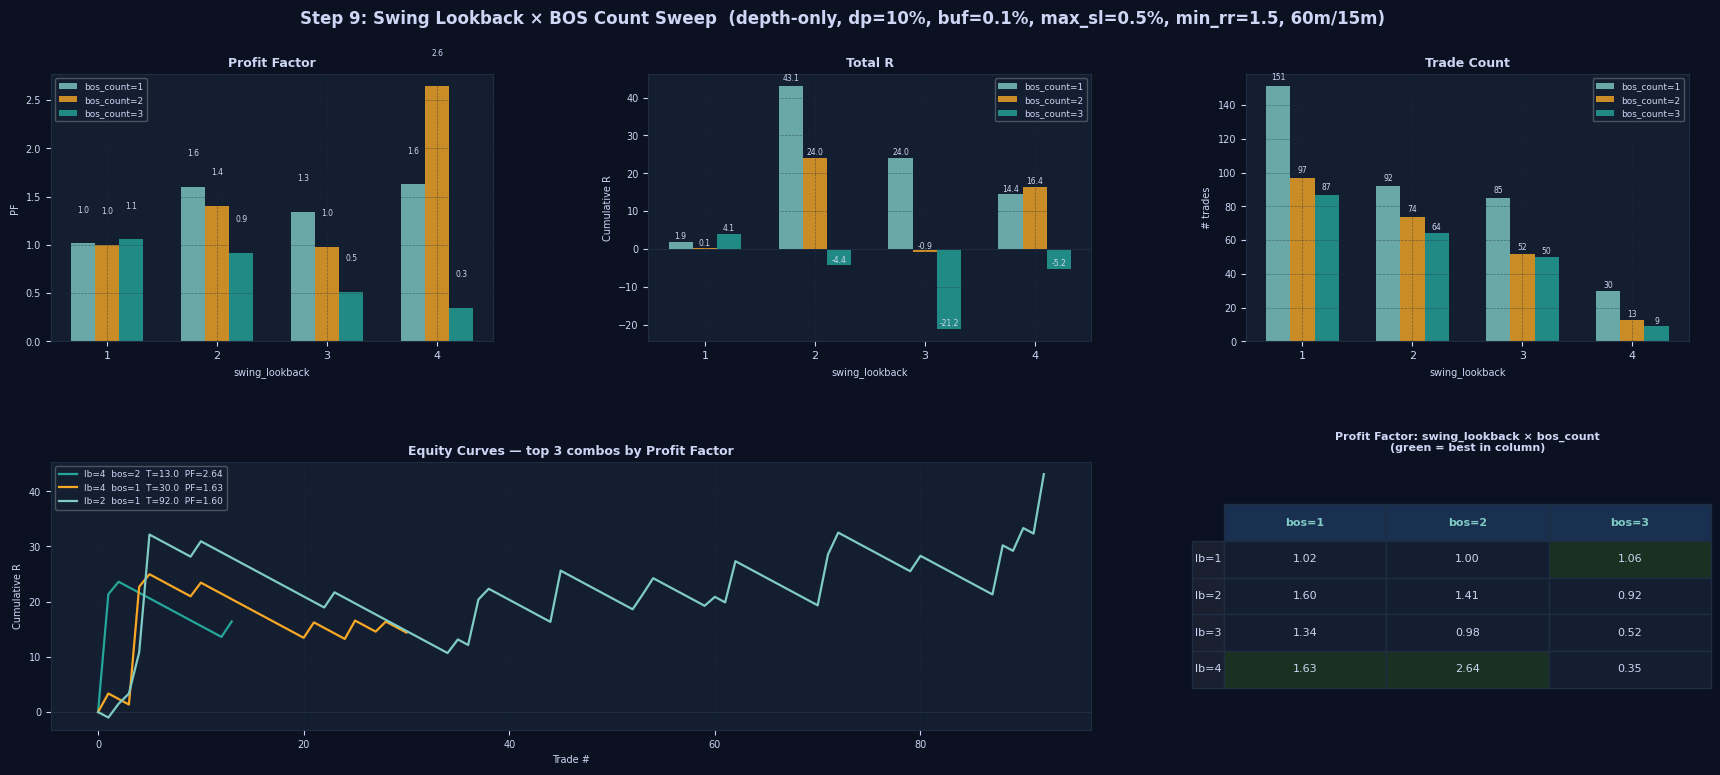

 lookback  bos_count  n_trades  win_rate    total_r  profit_factor    max_dd
        1          1       151  0.225166   1.938684       1.016570 26.000000
        1          2        97  0.195876   0.136664       1.001752 22.989170
        1          3        87  0.195402   4.056930       1.057956 19.138344
        2          1        92  0.217391  43.112673       1.598787 21.471403
        2          2        74  0.202703  24.030559       1.407298 24.011476
        2          3        64  0.171875  -4.351090       0.917904 23.139519
        3          1        85  0.176471  23.972348       1.342462 27.071875
        3          2        52  0.134615  -0.900438       0.979990 29.801966
        3          3        50  0.120000 -21.249340       0.517060 28.801966
        4          1        30  0.233333  14.396289       1.625926 11.727586
        4          2        13  0.230769  16.410115       2.641012 10.000000
        4          3         9  0.111111  -5.203446       0.349569  8.000000

In [27]:
LOOKBACKS  = [1, 2, 3, 4]
BOS_COUNTS = [1, 2, 3]
LB_BASE = dict(trend_tf="60m", entry_tf="15m",
               fvg_min_width_pct=0.002,
               fvg_entry_depth_pct=0.10,
               require_ltf_confirmation=False,
               sl_buffer_pct=0.001, max_sl_pct=0.005,
               min_rr=1.5)

# ── Run grid ────────────────────────────────────────────────────────────────
lb_records   = []
lb_trade_map = {}
for lb, bc in itertools.product(LOOKBACKS, BOS_COUNTS):
    p = BacktestParams(**LB_BASE, swing_lookback=lb, bos_count=bc)
    r = run_backtest(htf_raw, ltf_raw, p)
    lb_records.append(dict(
        lookback=lb, bos_count=bc,
        n_trades=r.n_trades, win_rate=r.win_rate,
        total_r=r.total_r, profit_factor=r.profit_factor,
        max_dd=r.max_drawdown_r,
    ))
    lb_trade_map[(lb, bc)] = [t.r_multiple for t in r.trades]

df_lb = pd.DataFrame(lb_records)

# ── Layout ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 8), facecolor=BG)
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35,
                        left=0.06, right=0.97, top=0.90, bottom=0.08)
ax_pf  = fig.add_subplot(gs[0, 0])
ax_tr  = fig.add_subplot(gs[0, 1])
ax_nt  = fig.add_subplot(gs[0, 2])
ax_eq  = fig.add_subplot(gs[1, 0:2])
ax_tbl = fig.add_subplot(gs[1, 2])

BC_COLORS = [CYAN, GOLD, GREEN]
bar_w = 0.22
x     = np.arange(len(LOOKBACKS))

for ax, col, title, ylbl in [
    (ax_pf, "profit_factor", "Profit Factor", "PF"),
    (ax_tr, "total_r",       "Total R",       "Cumulative R"),
    (ax_nt, "n_trades",      "Trade Count",   "# trades"),
]:
    style_ax(ax, title)
    for k, (bc, color) in enumerate(zip(BOS_COUNTS, BC_COLORS)):
        vals = [df_lb.loc[(df_lb.lookback == lb) & (df_lb.bos_count == bc), col].values[0]
                for lb in LOOKBACKS]
        offset = (k - 1) * bar_w
        bars = ax.bar(x + offset, vals, width=bar_w, color=color, alpha=0.80,
                      label=f"bos_count={bc}")
        for bar, v in zip(bars, vals):
            if v != 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + max(abs(v) * 0.02, 0.3),
                        f"{v:.1f}" if col != "n_trades" else str(int(v)),
                        ha="center", va="bottom", fontsize=5.5, color=FG)
    ax.set_xticks(x)
    ax.set_xticklabels([str(lb) for lb in LOOKBACKS], fontsize=8)
    ax.set_xlabel("swing_lookback", fontsize=7)
    ax.set_ylabel(ylbl, fontsize=7)
    ax.axhline(0, color=GRID, lw=0.7)
    ax.legend(fontsize=6.5, framealpha=0.3, labelcolor=FG)

# ── Equity curves (top-3 by PF) ──────────────────────────────────────────────
style_ax(ax_eq, "Equity Curves — top 3 combos by Profit Factor")
ax_eq.axhline(0, color=GRID, lw=0.8)
top3 = df_lb[df_lb.n_trades > 0].sort_values("profit_factor", ascending=False).head(3)
eq_colors = [GREEN, GOLD, CYAN]
for i, (_, row) in enumerate(top3.iterrows()):
    rs = lb_trade_map[(row.lookback, row.bos_count)]
    if not rs:
        continue
    eq  = np.concatenate([[0], np.cumsum(rs)])
    lbl = (f"lb={int(row.lookback)}  bos={int(row.bos_count)}  "
           f"T={row.n_trades}  PF={row.profit_factor:.2f}")
    ax_eq.plot(eq, color=eq_colors[i], lw=1.6, label=lbl)
ax_eq.legend(fontsize=6.5, framealpha=0.3, labelcolor=FG)
ax_eq.set_xlabel("Trade #", fontsize=7)
ax_eq.set_ylabel("Cumulative R", fontsize=7)

# ── Pivot table (PF) — highlight best per column ─────────────────────────────
ax_tbl.set_facecolor(BG2)
ax_tbl.axis("off")
pivot_lb = df_lb.pivot(index="lookback", columns="bos_count", values="profit_factor")
pivot_lb.index   = [f"lb={v}" for v in pivot_lb.index]
pivot_lb.columns = [f"bos={v}" for v in pivot_lb.columns]
_rows = [[f"{v:.2f}" for v in row] for row in pivot_lb.values]
tbl = ax_tbl.table(cellText=_rows,
                   rowLabels=list(pivot_lb.index),
                   colLabels=list(pivot_lb.columns),
                   cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.1, 2.2)
col_maxes = [max(float(_rows[r][c]) for r in range(len(_rows)))
             for c in range(len(_rows[0]))]
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(GRID)
    if row == 0:
        cell.set_facecolor("#1a3050")
        cell.set_text_props(color=CYAN, fontweight="bold")
    elif col == -1:
        cell.set_facecolor("#1a2030")
        cell.set_text_props(color=FG)
    else:
        v  = float(_rows[row - 1][col])
        fc = "#1a3020" if v == col_maxes[col] else BG2
        cell.set_facecolor(fc)
        cell.set_text_props(color=FG)
ax_tbl.set_title("Profit Factor: swing_lookback × bos_count\n(green = best in column)",
                  color=FG, fontsize=8, fontweight="bold", pad=8)

fig.suptitle("Step 9: Swing Lookback × BOS Count Sweep  (depth-only, dp=10%, buf=0.1%, max_sl=0.5%, min_rr=1.5, 60m/15m)",
             color=FG, fontsize=12, fontweight="bold")
plt.show()
print(df_lb.to_string(index=False))


## Step 10 — Displacement 参数扫描

`displacement_required` 控制 FVG 是否必须由"位移蜡烛"产生。位移蜡烛的判断基于前 N 根 K 线的**均值 range** 作为基准（`displacement_lookback`），中间 K 线 range 需超过基准的 `displacement_atr_mult` 倍，且实体占比 ≥ 50%。

**扫描维度：**
- `displacement_required`：[False, True]
- `displacement_lookback`：[3, 5, 10]（仅 True 时有效）
- `displacement_atr_mult`：[1.5, 2.0, 3.0]（仅 True 时有效）

固定最优参数：`dp=10%, buf=0.1%, max_sl=0.5%, min_rr=1.5`。

displacement=False : T= 92  PF=1.60  TotalR=43.1

 lookback  atr_mult  n_trades  win_rate   total_r  profit_factor  max_dd
        3       1.5         6  0.500000 15.220194       6.073398     1.0
        3       2.0         5  0.600000 16.220194       9.110097     1.0
        3       3.0         4  0.500000  8.754230       5.377115     1.0
        5       1.5         6  0.500000 15.220194       6.073398     1.0
        5       2.0         5  0.600000 16.220194       9.110097     1.0
        5       3.0         2  0.500000  7.254230       8.254230     1.0
       10       1.5         6  0.500000 15.220194       6.073398     1.0
       10       2.0         3  0.666667 14.720194      15.720194     1.0
       10       3.0         1  0.000000 -1.000000       0.000000     1.0


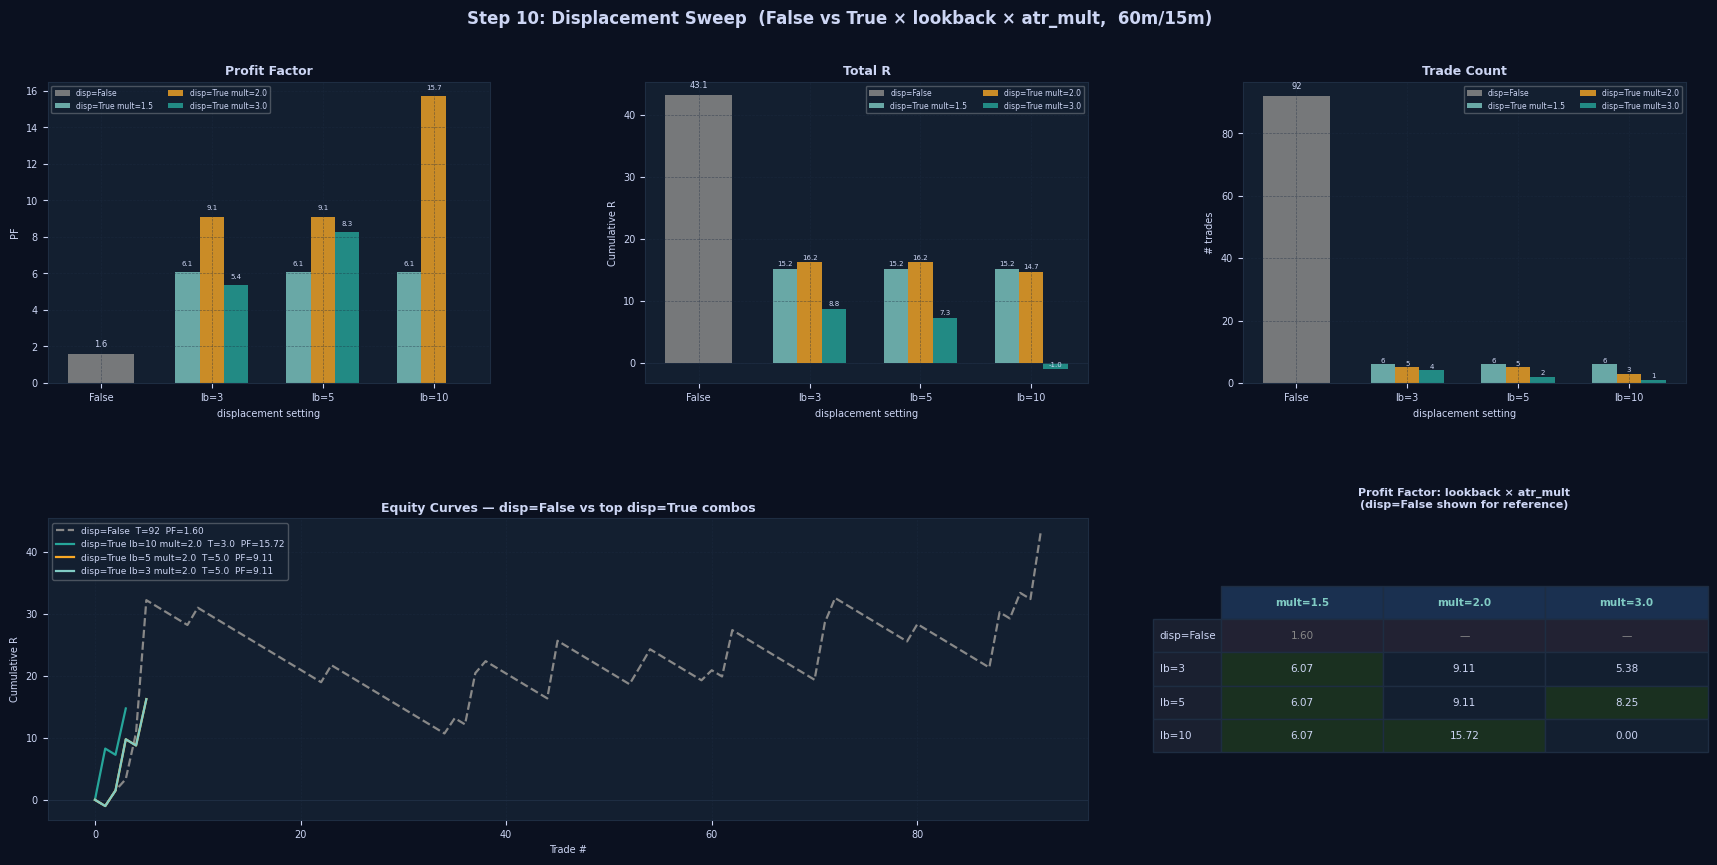

In [28]:
LOOKBACKS = [3, 5, 10]
ATR_MULTS = [1.5, 2.0, 3.0]
DISP_BASE = dict(
    trend_tf="60m", entry_tf="15m",
    swing_lookback=2, bos_count=1,
    fvg_min_width_pct=0.002,
    fvg_entry_depth_pct=0.10,
    require_ltf_confirmation=False,
    sl_buffer_pct=0.001, max_sl_pct=0.005,
    min_rr=1.5,
)

# ── Run: displacement_required=False (single run, lookback/mult irrelevant) ──
p_off  = BacktestParams(**DISP_BASE, displacement_required=False)
r_off  = run_backtest(htf_raw, ltf_raw, p_off)
off_rs = [t.r_multiple for t in r_off.trades]

# ── Run: displacement_required=True, sweep lookback × atr_mult ───────────────
disp_records   = []
disp_trade_map = {}
for lb, mult in itertools.product(LOOKBACKS, ATR_MULTS):
    p = BacktestParams(**DISP_BASE,
                       displacement_required=True,
                       displacement_lookback=lb,
                       displacement_atr_mult=mult)
    r = run_backtest(htf_raw, ltf_raw, p)
    disp_records.append(dict(
        lookback=lb, atr_mult=mult,
        n_trades=r.n_trades, win_rate=r.win_rate,
        total_r=r.total_r, profit_factor=r.profit_factor,
        max_dd=r.max_drawdown_r,
    ))
    disp_trade_map[(lb, mult)] = [t.r_multiple for t in r.trades]

df_disp = pd.DataFrame(disp_records)

print(f"displacement=False : T={r_off.n_trades:3d}  PF={r_off.profit_factor:.2f}  TotalR={r_off.total_r:.1f}")
print()
print(df_disp.to_string(index=False))

# ── Layout ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 9), facecolor=BG)
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35,
                        left=0.06, right=0.97, top=0.90, bottom=0.08)
ax_pf  = fig.add_subplot(gs[0, 0])
ax_tr  = fig.add_subplot(gs[0, 1])
ax_nt  = fig.add_subplot(gs[0, 2])
ax_eq  = fig.add_subplot(gs[1, 0:2])
ax_tbl = fig.add_subplot(gs[1, 2])

MULT_COLORS = {1.5: CYAN, 2.0: GOLD, 3.0: GREEN}
# For bar positioning: False occupies slot 0, True combos follow
x_labels = ["False"] + [f"lb={lb}" for lb in LOOKBACKS]
x_pos    = np.arange(len(x_labels))

# ── Bar charts ────────────────────────────────────────────────────────────────
for ax, col, title, ylbl in [
    (ax_pf, "profit_factor", "Profit Factor", "PF"),
    (ax_tr, "total_r",       "Total R",       "Cumulative R"),
    (ax_nt, "n_trades",      "Trade Count",   "# trades"),
]:
    style_ax(ax, title)
    ax.axhline(0, color=GRID, lw=0.5)

    # displacement=False bar (no grouping needed)
    false_val = getattr(r_off, col if col != "n_trades" else "n_trades")
    false_val = r_off.n_trades if col == "n_trades" else getattr(r_off, col)
    ax.bar(0, false_val, width=0.6, color='#888888', alpha=0.85, label="disp=False")
    fmt = f"{false_val:.1f}" if col != "n_trades" else str(int(false_val))
    if false_val != 0:
        ax.text(0, false_val + max(abs(false_val)*0.02, 0.3), fmt,
                ha="center", va="bottom", fontsize=6, color=FG)

    # displacement=True bars grouped by atr_mult
    bar_w = 0.22
    for k, (mult, color) in enumerate(MULT_COLORS.items()):
        vals = [df_disp.loc[(df_disp.lookback == lb) & (df_disp.atr_mult == mult), col].values[0]
                for lb in LOOKBACKS]
        offsets = np.arange(1, len(LOOKBACKS)+1) + (k-1)*bar_w
        bars = ax.bar(offsets, vals, width=bar_w, color=color, alpha=0.80,
                      label=f"disp=True mult={mult}")
        for bar, v in zip(bars, vals):
            if v != 0:
                ax.text(bar.get_x()+bar.get_width()/2,
                        bar.get_height()+max(abs(v)*0.02, 0.3),
                        f"{v:.1f}" if col != "n_trades" else str(int(v)),
                        ha="center", va="bottom", fontsize=5, color=FG)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=7)
    ax.set_xlabel("displacement setting", fontsize=7)
    ax.set_ylabel(ylbl, fontsize=7)
    ax.legend(fontsize=5.5, framealpha=0.3, labelcolor=FG, ncol=2)

# ── Equity curves: False + top-3 True combos ─────────────────────────────────
style_ax(ax_eq, "Equity Curves — disp=False vs top disp=True combos")
ax_eq.axhline(0, color=GRID, lw=0.8)
if off_rs:
    eq = np.concatenate([[0], np.cumsum(off_rs)])
    ax_eq.plot(eq, color='#888888', lw=1.6, ls='--',
               label=f"disp=False  T={r_off.n_trades}  PF={r_off.profit_factor:.2f}")

top3 = df_disp[df_disp.n_trades > 0].sort_values("profit_factor", ascending=False).head(3)
for i, (_, row) in enumerate(top3.iterrows()):
    rs = disp_trade_map[(row.lookback, row.atr_mult)]
    if not rs:
        continue
    eq  = np.concatenate([[0], np.cumsum(rs)])
    lbl = (f"disp=True lb={int(row.lookback)} mult={row.atr_mult}  "
           f"T={row.n_trades}  PF={row.profit_factor:.2f}")
    ax_eq.plot(eq, color=[GREEN,GOLD,CYAN][i], lw=1.6, label=lbl)
ax_eq.legend(fontsize=6.5, framealpha=0.3, labelcolor=FG)
ax_eq.set_xlabel("Trade #", fontsize=7)
ax_eq.set_ylabel("Cumulative R", fontsize=7)

# ── Pivot table: PF (disp=True only) ─────────────────────────────────────────
ax_tbl.set_facecolor(BG2)
ax_tbl.axis("off")
pivot = df_disp.pivot(index="lookback", columns="atr_mult", values="profit_factor")
pivot.index   = [f"lb={v}" for v in pivot.index]
pivot.columns = [f"mult={v}" for v in pivot.columns]
_rows = [[f"{v:.2f}" for v in row] for row in pivot.values]
# add False row at top
false_pf = f"{r_off.profit_factor:.2f}"
_rows_full = [[false_pf, "—", "—"]] + _rows
row_labels = ["disp=False"] + list(pivot.index)
col_maxes  = [max(float(r[c]) for r in _rows if r[c] != "—")
              for c in range(len(_rows[0]))]
tbl = ax_tbl.table(cellText=_rows_full,
                   rowLabels=row_labels,
                   colLabels=list(pivot.columns),
                   cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.scale(1.1, 2.0)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(GRID)
    if row == 0:
        cell.set_facecolor("#1a3050")
        cell.set_text_props(color=CYAN, fontweight="bold")
    elif col == -1:
        cell.set_facecolor("#1a2030")
        cell.set_text_props(color=FG)
    elif row == 1:  # disp=False row
        cell.set_facecolor("#222233")
        cell.set_text_props(color='#888888')
    else:
        try:
            v  = float(_rows_full[row-1][col])
            fc = "#1a3020" if v == col_maxes[col] else BG2
        except ValueError:
            fc = BG2
        cell.set_facecolor(fc)
        cell.set_text_props(color=FG)
ax_tbl.set_title("Profit Factor: lookback × atr_mult\n(disp=False shown for reference)",
                  color=FG, fontsize=8, fontweight="bold", pad=8)

fig.suptitle(
    "Step 10: Displacement Sweep  (False vs True × lookback × atr_mult,  60m/15m)",
    color=FG, fontsize=12, fontweight="bold",
)
plt.show()
